## STEP 0. 환경/DB 연결

In [9]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

user = "team8_admin"
password = "admin1!"
host = "34.50.4.76"
port = 3306
database = "team8_11"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")
print("DB 연결 완료")


DB 연결 완료


## STEP 1. 원천 데이터 로드

In [10]:
noise = pd.read_sql("SELECT * FROM noise_integrated", engine)
vibration = pd.read_sql("SELECT * FROM vibration_integrated", engine)
noise_com = pd.read_sql("SELECT * FROM noise_complaint", engine)

display(noise.head())
display(vibration.head())
display(noise_com.head())
print(noise.shape, vibration.shape, noise_com.shape)

,gu_code,자치구,지역,2201,2202,2203,2204,2205,2206,2207,...,2403,2404,2405,2406,2407,2408,2409,2410,2411,2412
0,11110,종로구,main_street,49.931213,50.590938,50.130740,50.804956,50.191871,50.087831,50.443271,...,49.307064,48.380290,48.914960,48.538910,50.054460,50.515551,48.821852,48.176839,48.377358,49.302819
1,11110,종로구,public_facilities,43.971979,44.022604,43.003913,41.813812,42.290155,44.858310,46.292023,...,NaN,47.050820,47.609130,46.874636,43.589744,48.293388,44.669930,44.621438,45.353436,45.655120
2,11110,종로구,residential_area,45.520378,45.725953,44.843993,44.057325,44.136669,45.276522,45.733778,...,47.200909,46.136474,44.932364,44.327932,46.151358,47.243382,46.140823,45.427398,45.610119,45.992169
3,11110,종로구,roads_and_parks,59.954187,60.463100,60.179632,60.267141,60.732937,61.859122,60.838969,...,61.310135,61.009239,61.184323,61.430839,61.114387,61.171555,59.274934,57.637162,57.220747,57.967718
4,11140,중구,commercial_area,50.209353,50.458342,49.859668,49.117785,49.086536,49.749223,49.640019,...,49.807018,49.536946,49.513889,49.221207,49.559380,48.902965,48.749304,48.881081,48.887500,48.959641


,gu_code,자치구,2201_v_x,2201_v_y,2201_v_z,2202_v_x,2202_v_y,2202_v_z,2203_v_x,2203_v_y,...,2409_v_z,2410_v_x,2410_v_y,2410_v_z,2411_v_x,2411_v_y,2411_v_z,2412_v_x,2412_v_y,2412_v_z
0,11110,종로구,0.031804,0.048224,1.043984,0.031261,0.047986,1.043320,0.029158,0.049911,...,1.025650,0.030269,0.046990,1.032569,0.029718,0.045098,1.037849,0.033246,0.044603,1.043928
1,11140,중구,0.023529,0.060963,1.039963,0.023010,0.060624,1.039318,0.022582,0.062436,...,0.987247,0.023921,0.069950,0.991803,0.021419,0.066447,0.995186,0.021225,0.063049,1.004250
2,11170,용산구,0.025965,0.056074,1.037595,0.025152,0.056917,1.037712,0.022488,0.059391,...,1.000721,0.021024,0.061890,1.014460,0.022701,0.060523,1.026247,0.024616,0.059461,1.030667
3,11200,성동구,0.025986,0.060366,1.040970,0.025563,0.060255,1.040053,0.025220,0.060107,...,1.018945,0.028802,0.062090,1.023512,0.027610,0.061040,1.028999,0.027338,0.060620,1.035975
4,11215,광진구,0.029504,0.059864,1.042857,0.029074,0.058764,1.041972,0.026966,0.057105,...,1.021794,0.028312,0.057976,1.027340,0.030016,0.061093,1.033652,0.030518,0.063062,1.043562


,자치구별(2),2022,2022_1,2023,2023_1,2024,2024_1
0,소계,83743,74257,75931,63452,79451,59263
1,종로구,2800,2480,2512,2200,2255,2057
2,중구,2820,2820,1678,1223,1360,1180
3,용산구,3549,3080,3614,3175,3053,2673
4,성동구,2916,2631,2691,2574,2589,2477


(130, 39) (25, 110) (26, 7)


## STEP 2. 월별 분석용 long 포맷 만들

In [11]:
# 소음 long
noise_long = noise.melt(
    id_vars=["gu_code", "자치구", "지역"],
    var_name="연월",
    value_name="소음값"
)
noise_long["소음값"] = pd.to_numeric(noise_long["소음값"], errors="coerce")
noise_long["연도"] = ("20" + noise_long["연월"].str[:2]).astype(int)
noise_long["월"] = noise_long["연월"].str[2:4].astype(int)

# 진동 long
vibration_long = vibration.melt(
    id_vars=["gu_code", "자치구"],
    var_name="연월축",
    value_name="진동값"
)
vibration_long["진동값"] = pd.to_numeric(vibration_long["진동값"], errors="coerce")
vibration_long["연도"] = ("20" + vibration_long["연월축"].str[:2]).astype(int)
vibration_long["월"] = vibration_long["연월축"].str[2:4].astype(int)
vibration_long["축"] = vibration_long["연월축"].str[-1]

display(noise_long.head())
display(vibration_long.head())


,gu_code,자치구,지역,연월,소음값,연도,월
0,11110,종로구,main_street,2201,49.931213,2022,1
1,11110,종로구,public_facilities,2201,43.971979,2022,1
2,11110,종로구,residential_area,2201,45.520378,2022,1
3,11110,종로구,roads_and_parks,2201,59.954187,2022,1
4,11140,중구,commercial_area,2201,50.209353,2022,1


,gu_code,자치구,연월축,진동값,연도,월,축
0,11110,종로구,2201_v_x,0.031804,2022,1,x
1,11140,중구,2201_v_x,0.023529,2022,1,x
2,11170,용산구,2201_v_x,0.025965,2022,1,x
3,11200,성동구,2201_v_x,0.025986,2022,1,x
4,11215,광진구,2201_v_x,0.029504,2022,1,x


## STEP 3. 월별 바차트 (전체)

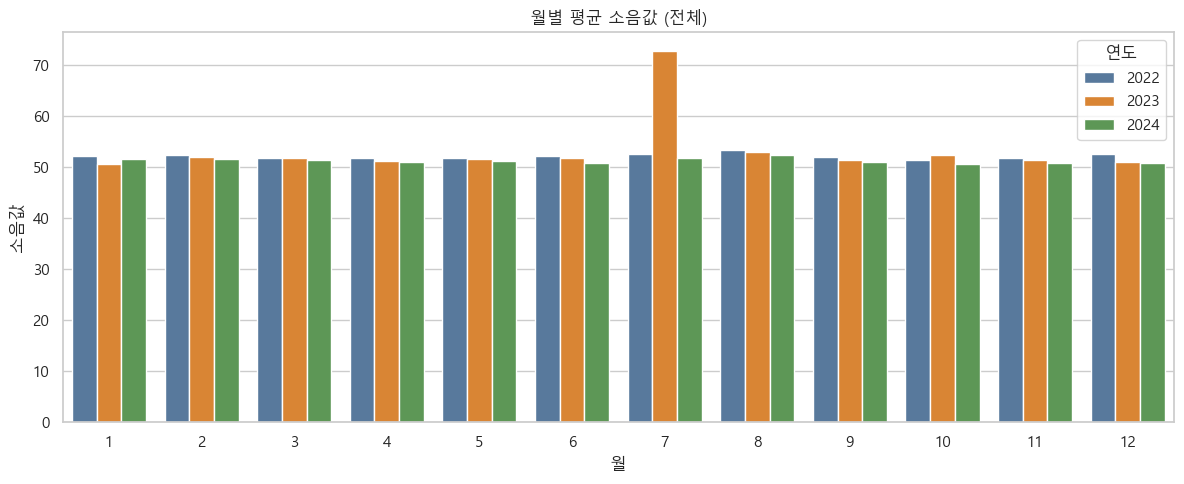

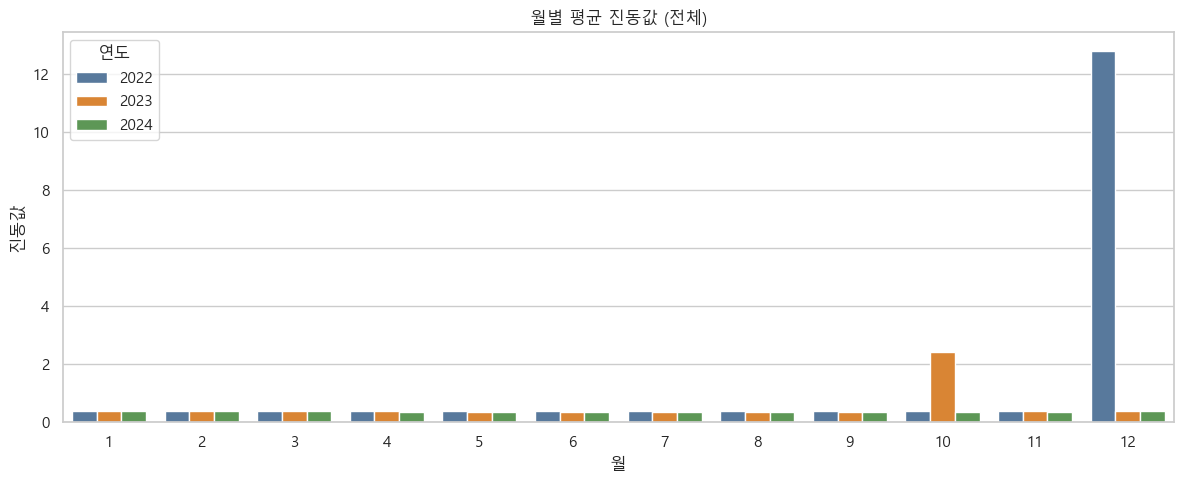

In [12]:
monthly_noise_all = noise_long.groupby(["연도", "월"], as_index=False)["소음값"].mean()
monthly_vib_all = vibration_long.groupby(["연도", "월"], as_index=False)["진동값"].mean()

plt.figure(figsize=(12,5))
sns.barplot(data=monthly_noise_all, x="월", y="소음값", hue="연도", palette=["#4C78A8", "#F58518", "#54A24B"])
plt.title("월별 평균 소음값 (전체)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=monthly_vib_all, x="월", y="진동값", hue="연도", palette=["#4C78A8", "#F58518", "#54A24B"])
plt.title("월별 평균 진동값 (전체)")
plt.tight_layout()
plt.show()


In [13]:
## 해석 코드 A. 월별 바차트 결과 읽기 (전체)
## 무엇을 보나: 월 피크/저점, 연도별 평균 차이

# 월별 피크/저점
a_month = monthly_noise_all.copy()
peak_row = a_month.loc[a_month["소음값"].idxmax()]
low_row = a_month.loc[a_month["소음값"].idxmin()]

print(f"[전체 소음] 최고 월: {int(peak_row['연도'])}년 {int(peak_row['월'])}월, 값={peak_row['소음값']:.2f}")
print(f"[전체 소음] 최저 월: {int(low_row['연도'])}년 {int(low_row['월'])}월, 값={low_row['소음값']:.2f}")

# 연도별 평균
display(a_month.groupby("연도", as_index=False)["소음값"].mean().rename(columns={"소음값":"연평균소음"}))

[전체 소음] 최고 월: 2023년 7월, 값=72.72
[전체 소음] 최저 월: 2024년 10월, 값=50.49


,연도,연평균소음
0,2022,52.087067
1,2023,53.384288
2,2024,51.194829


In [14]:
# 진동 월별 피크/저점 + 연도별 평균
# monthly_vib_all: [연도, 월, 진동값] 가 이미 있다고 가정

v_month = monthly_vib_all.copy()

peak_v = v_month.loc[v_month["진동값"].idxmax()]
low_v = v_month.loc[v_month["진동값"].idxmin()]

print(f"[전체 진동] 최고 월: {int(peak_v['연도'])}년 {int(peak_v['월'])}월, 값={peak_v['진동값']:.2f}")
print(f"[전체 진동] 최저 월: {int(low_v['연도'])}년 {int(low_v['월'])}월, 값={low_v['진동값']:.2f}")

# 연도별 평균
display(
    v_month.groupby("연도", as_index=False)["진동값"]
    .mean()
    .rename(columns={"진동값": "연평균진동"})
)

[전체 진동] 최고 월: 2022년 12월, 값=12.81
[전체 진동] 최저 월: 2024년 8월, 값=0.37


,연도,연평균진동
0,2022,1.408944
1,2023,0.543543
2,2024,0.370194


## STEP 4. 자치구별 월별 바차트 (소음/진동)
- 목적: 자치구마다 월 패턴이 다른지 확인

In [15]:
# 시각화 대상 자치구 선택
# 너무 많으면 그래프가 복잡해지니 상위 N개 또는 직접 선택

# 방법 A: 소음 평균 상위 N개
topN = 8
top_gu_noise = (
    noise_long.groupby("자치구", as_index=False)["소음값"].mean()
    .sort_values("소음값", ascending=False)
    .head(topN)["자치구"]
)

# 필요하면 방법 B로 직접 지정
# top_gu_noise = ["강남구", "송파구", "중구", "마포구"]

print("소음 시각화 대상:", list(top_gu_noise))

소음 시각화 대상: ['은평구', '성동구', '강서구', '강남구', '강동구', '성북구', '동대문구', '용산구']


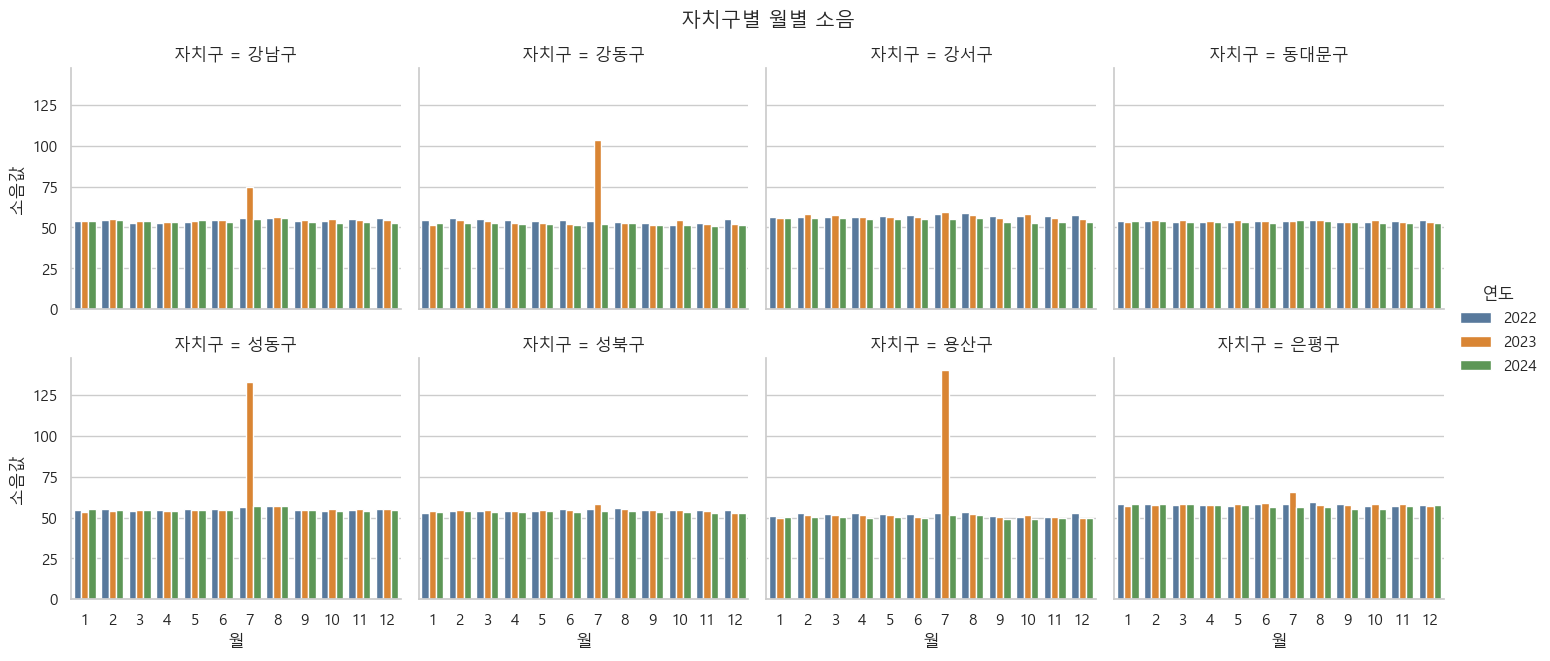

In [16]:
# 자치구별 월별 소음 바차트
plot_noise_gu = noise_long[noise_long["자치구"].isin(top_gu_noise)].copy()
plot_noise_gu = plot_noise_gu.groupby(["자치구", "연도", "월"], as_index=False)["소음값"].mean()

g = sns.catplot(
    data=plot_noise_gu,
    kind="bar",
    x="월", y="소음값", hue="연도",
    col="자치구", col_wrap=4,
    height=3.2, aspect=1.15,
    palette=["#4C78A8", "#F58518", "#54A24B"]
)
g.fig.suptitle("자치구별 월별 소음", y=1.03)
plt.show()

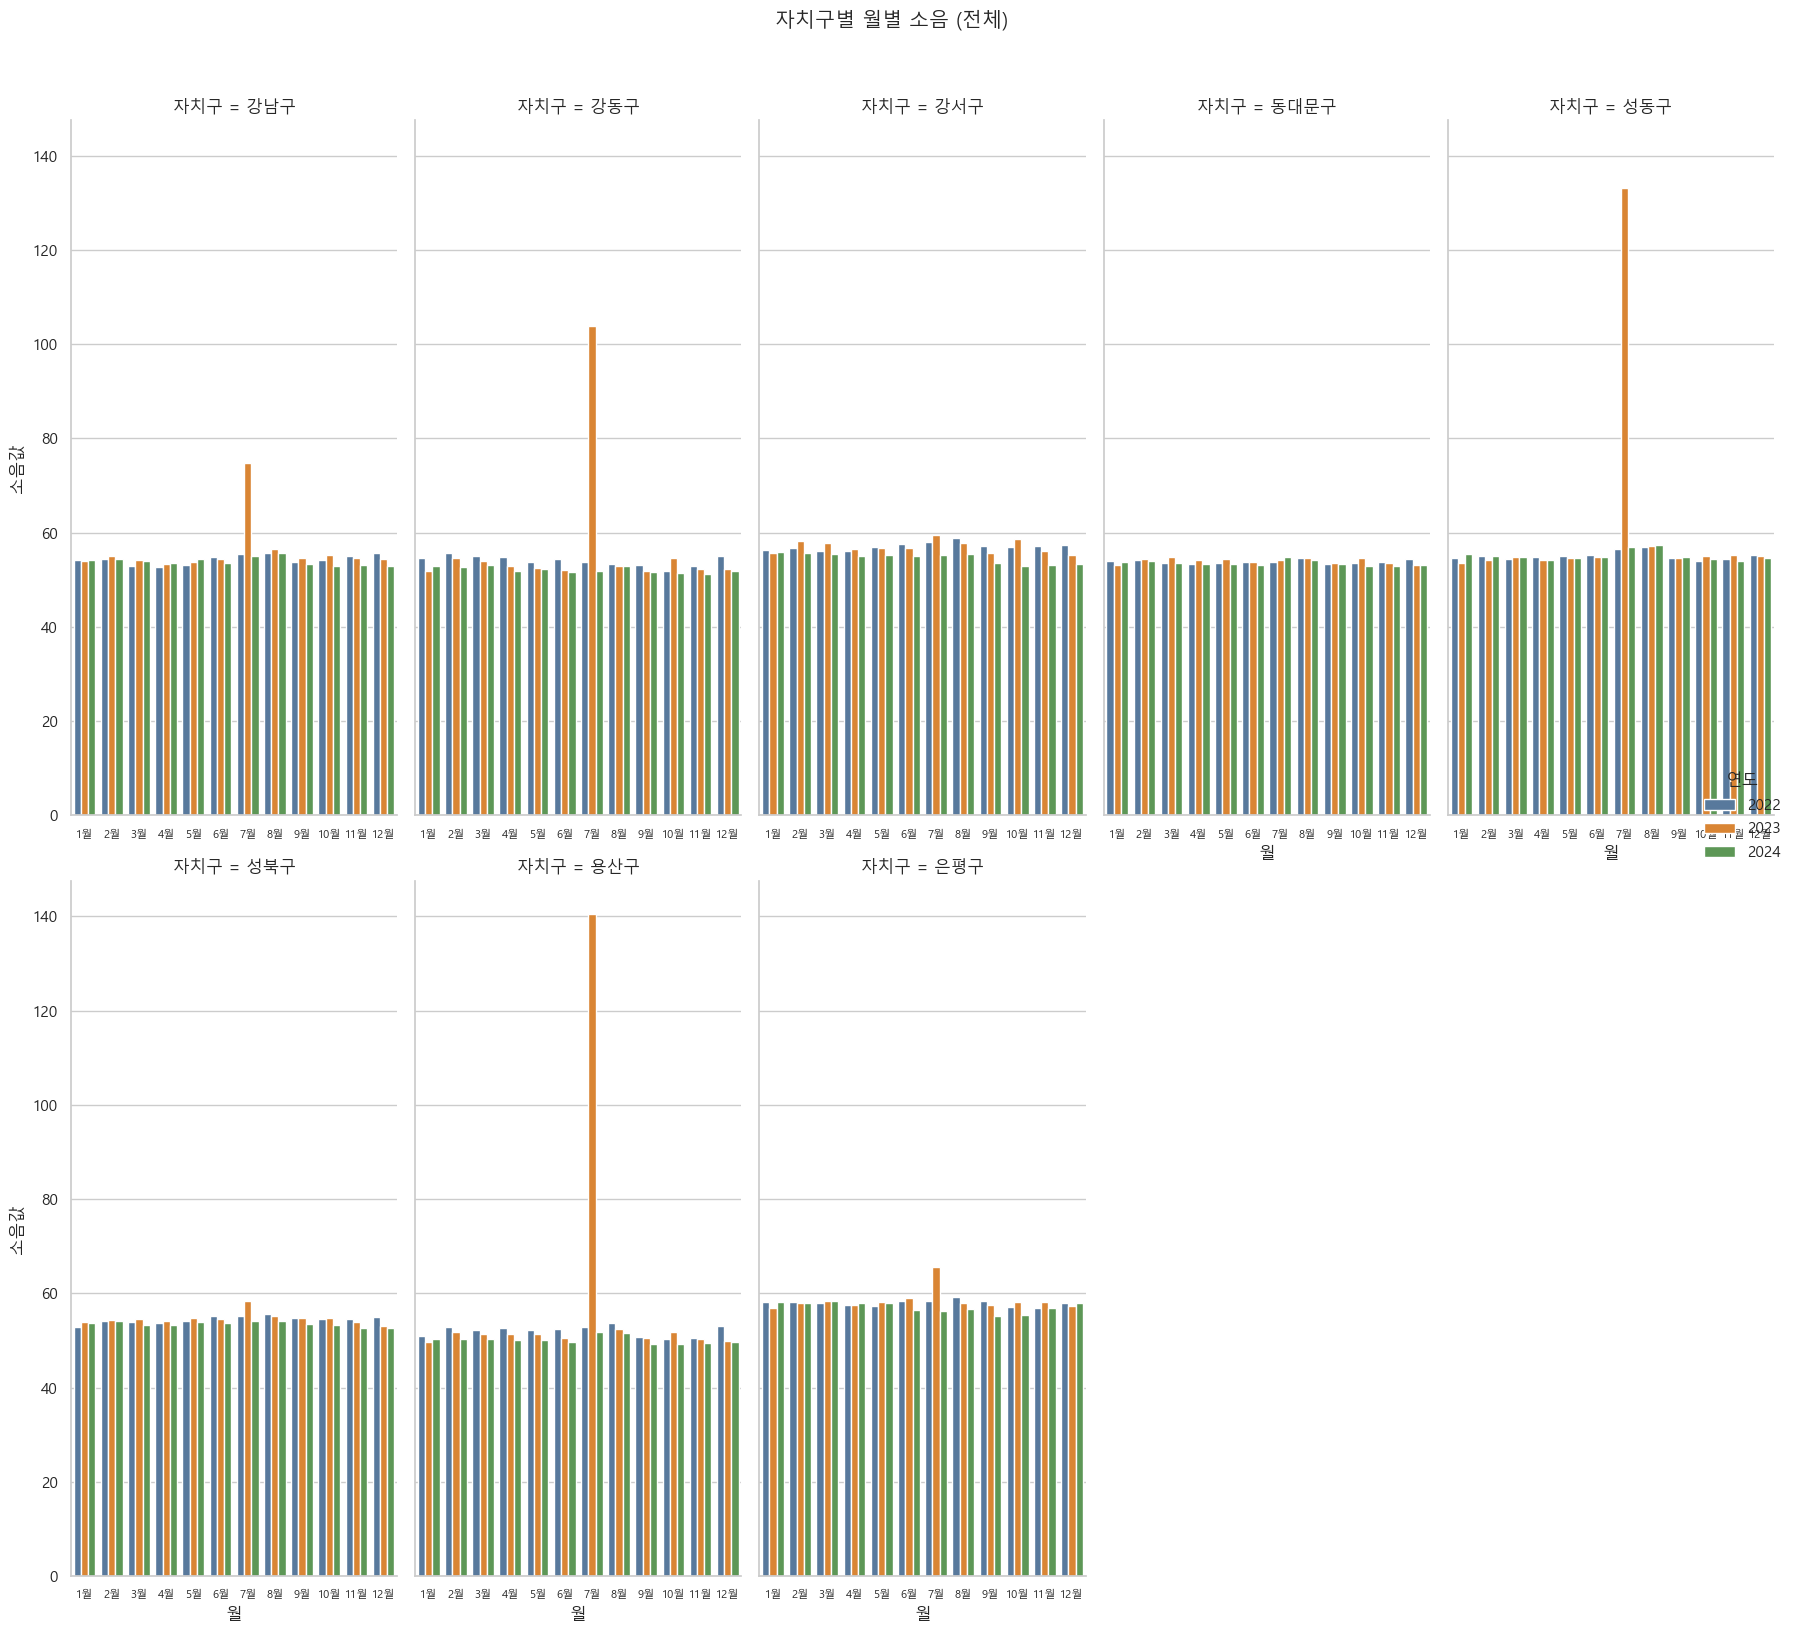

In [17]:
# 전체 자치구 월별 소음 (모든 자치구)
g = sns.catplot(
    data=plot_noise_gu,
    kind="bar",
    x="월", y="소음값", hue="연도",
    col="자치구", col_wrap=5,
    height=3.0, aspect=1.05,
    palette=["#4C78A8", "#F58518", "#54A24B"]
)

# 모든 서브플롯에 월 라벨 강제 표시
for ax in g.axes.flat:
    ax.set_xticks(range(12))
    ax.set_xticklabels([f"{m}월" for m in range(1, 13)], rotation=0, fontsize=8)
    ax.tick_params(axis="x", labelbottom=True)  # 핵심: 모든 축에 라벨 표시
    ax.set_xlabel("월")

g.set_ylabels("소음값")
g.fig.suptitle("자치구별 월별 소음 (전체)", y=1.02)
g.fig.set_size_inches(18, 16)
plt.tight_layout()
plt.show()

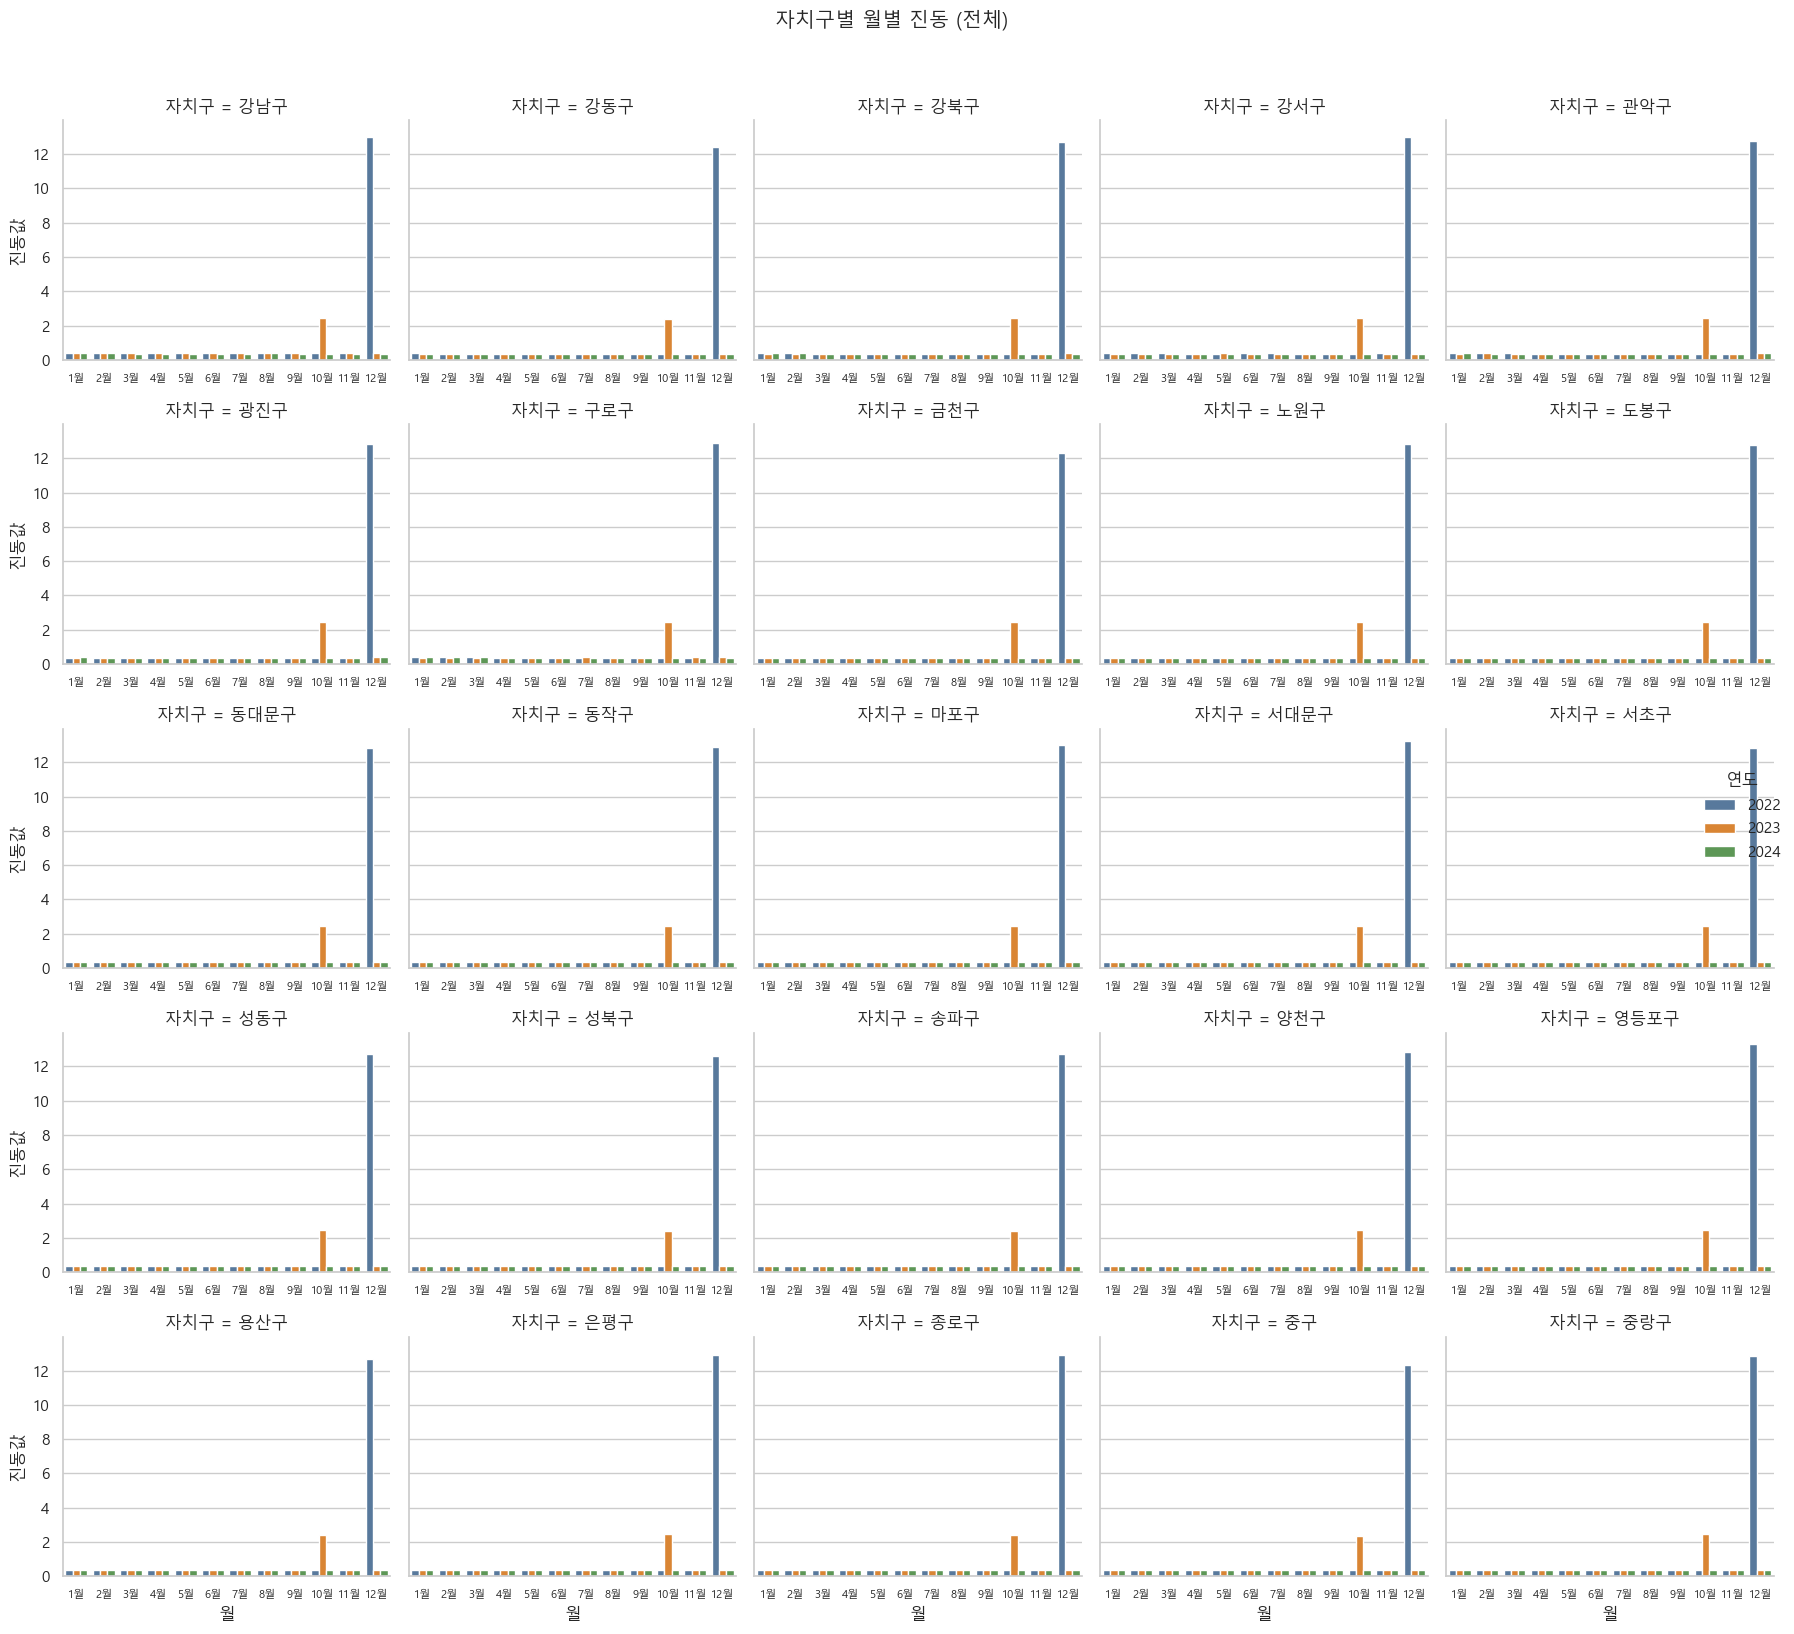

In [18]:
# 자치구별 월별 진동 바차트 (전체 자치구)
plot_vib_gu = (
    vibration_long
    .groupby(["자치구", "연도", "월"], as_index=False)["진동값"]
    .mean()
)

g = sns.catplot(
    data=plot_vib_gu,
    kind="bar",
    x="월", y="진동값", hue="연도",
    col="자치구", col_wrap=5,
    height=3.0, aspect=1.05,
    palette=["#4C78A8", "#F58518", "#54A24B"]
)

# 모든 서브플롯에 월 라벨 표시
for ax in g.axes.flat:
    ax.set_xticks(range(12))
    ax.set_xticklabels([f"{m}월" for m in range(1, 13)], fontsize=8)
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_xlabel("월")

g.set_ylabels("진동값")
g.fig.suptitle("자치구별 월별 진동 (전체)", y=1.02)
g.fig.set_size_inches(18, 16)
plt.tight_layout()
plt.show()

In [19]:
## 해석 코드 B. 자치구별 소음/진동 차이 읽기
## 무엇을 보나: "항상 높은 구", "특정 월만 튀는 구", "변동 큰 구"

# 자치구별 평균/변동
noise_gu_summary = (
    noise_long.groupby("자치구", as_index=False)["소음값"]
    .agg(평균소음="mean", 표준편차="std", 최대값="max", 최소값="min")
)
noise_gu_summary["범위(max-min)"] = noise_gu_summary["최대값"] - noise_gu_summary["최소값"]

print("[평균소음 상위 10]")
display(noise_gu_summary.sort_values("평균소음", ascending=False).head(10))

print("[변동성(표준편차) 상위 10]")
display(noise_gu_summary.sort_values("표준편차", ascending=False).head(10))

[평균소음 상위 10]


,자치구,평균소음,표준편차,최대값,최소값,범위(max-min)
21,은평구,57.897643,7.616556,83.178880,45.314319,37.864562
15,성동구,57.207076,30.069273,476.454616,45.457212,430.997405
3,강서구,56.278129,6.549360,66.807046,44.067372,22.739674
0,강남구,54.864397,9.387670,149.035011,42.890973,106.144038
1,강동구,54.423334,20.154570,336.269203,37.041509,299.227694
16,성북구,54.286526,4.812745,60.136138,45.032976,15.103162
10,동대문구,53.793013,7.671500,64.753872,43.950136,20.803736
20,용산구,53.654428,30.793076,407.857269,42.671647,365.185621
12,마포구,53.585416,17.869999,273.150109,43.218692,229.931417
14,서초구,53.531228,11.074678,162.593972,41.471290,121.122682


[변동성(표준편차) 상위 10]


,자치구,평균소음,표준편차,최대값,최소값,범위(max-min)
20,용산구,53.654428,30.793076,407.857269,42.671647,365.185621
15,성동구,57.207076,30.069273,476.454616,45.457212,430.997405
1,강동구,54.423334,20.154570,336.269203,37.041509,299.227694
12,마포구,53.585416,17.869999,273.150109,43.218692,229.931417
5,광진구,51.691240,14.026173,199.956213,35.070990,164.885223
14,서초구,53.531228,11.074678,162.593972,41.471290,121.122682
22,종로구,51.534794,10.797471,151.427176,41.813812,109.613364
0,강남구,54.864397,9.387670,149.035011,42.890973,106.144038
2,강북구,50.834656,8.692530,160.563229,46.055866,114.507363
6,구로구,50.145730,8.004722,66.233971,42.386332,23.847639


In [20]:
# 비정상 급등치 후보(IQR 기준)
q1 = noise_long["소음값"].quantile(0.25)
q3 = noise_long["소음값"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

outlier_rows = noise_long[noise_long["소음값"] > upper].copy()
print("소음 이상치 기준 상한:", round(upper,2))
print("이상치 행 수:", len(outlier_rows))

display(
    outlier_rows.groupby(["자치구","연도","월"], as_index=False)["소음값"]
    .mean()
    .sort_values("소음값", ascending=False)
    .head(20)
)

소음 이상치 기준 상한: 71.79
이상치 행 수: 23


,자치구,연도,월,소음값
11,용산구,2023,7,407.857269
9,성동구,2023,7,277.797954
1,강동구,2023,7,237.634179
6,마포구,2023,7,213.422221
3,광진구,2023,7,199.956213
8,서초구,2023,7,162.593972
2,강북구,2023,7,160.563229
13,종로구,2023,7,115.365158
14,중구,2023,7,114.721714
0,강남구,2023,7,114.249962


In [21]:
# 자치구별 평균/변동
vib_gu_summary = (
    vibration_long.groupby("자치구", as_index=False)["진동값"]
    .agg(평균진동="mean", 표준편차="std", 최대값="max", 최소값="min")
)
vib_gu_summary["범위(max-min)"] = vib_gu_summary["최대값"] - vib_gu_summary["최소값"]

print("[평균진동 상위 10]")
display(vib_gu_summary.sort_values("평균진동", ascending=False).head(10))

print("[변동성(표준편차) 상위 10]")
display(vib_gu_summary.sort_values("표준편차", ascending=False).head(10))

[평균진동 상위 10]


,자치구,평균진동,표준편차,최대값,최소값,범위(max-min)
19,영등포구,0.790456,3.608916,37.054933,0.024354,37.030579
13,서대문구,0.789998,3.545964,36.404556,0.026761,36.377795
12,마포구,0.783662,3.486838,35.765959,0.027779,35.738180
24,중랑구,0.781817,3.462318,35.504468,0.027118,35.477350
0,강남구,0.781784,3.465643,35.540183,0.026068,35.514114
10,동대문구,0.781281,3.477253,35.654433,0.026824,35.627610
21,은평구,0.780788,3.475967,35.636712,0.026430,35.610282
6,구로구,0.780106,3.468721,35.565488,0.025097,35.540391
14,서초구,0.777123,3.445685,35.324216,0.022291,35.301925
9,도봉구,0.776910,3.430015,35.164184,0.024531,35.139653


[변동성(표준편차) 상위 10]


,자치구,평균진동,표준편차,최대값,최소값,범위(max-min)
19,영등포구,0.790456,3.608916,37.054933,0.024354,37.030579
13,서대문구,0.789998,3.545964,36.404556,0.026761,36.377795
3,강서구,0.773025,3.520820,36.131830,0.024624,36.107206
22,종로구,0.775986,3.507154,35.984552,0.026999,35.957553
12,마포구,0.783662,3.486838,35.765959,0.027779,35.738180
10,동대문구,0.781281,3.477253,35.654433,0.026824,35.627610
21,은평구,0.780788,3.475967,35.636712,0.026430,35.610282
18,양천구,0.774162,3.474071,35.633593,0.025451,35.608142
6,구로구,0.780106,3.468721,35.565488,0.025097,35.540391
11,동작구,0.771595,3.466170,35.545673,0.021988,35.523685


In [22]:
# 비정상 급등치 후보(IQR 기준)
q1_v = vibration_long["진동값"].quantile(0.25)
q3_v = vibration_long["진동값"].quantile(0.75)
iqr_v = q3_v - q1_v
upper_v = q3_v + 1.5 * iqr_v

vib_outlier_rows = vibration_long[vibration_long["진동값"] > upper_v].copy()
print("진동 이상치 기준 상한:", round(upper_v, 2))
print("이상치 행 수:", len(vib_outlier_rows))

display(
    vib_outlier_rows.groupby(["자치구", "연도", "월"], as_index=False)["진동값"]
    .mean()
    .sort_values("진동값", ascending=False)
    .head(20)
)

진동 이상치 기준 상한: 2.51
이상치 행 수: 50


,자치구,연도,월,진동값
38,영등포구,2022,12,37.054933
26,서대문구,2022,12,36.404556
6,강서구,2022,12,36.131830
44,종로구,2022,12,35.984552
24,마포구,2022,12,35.765959
20,동대문구,2022,12,35.654433
42,은평구,2022,12,35.636712
36,양천구,2022,12,35.633593
12,구로구,2022,12,35.565488
22,동작구,2022,12,35.545673


## STEP 5. 자치구별 상관 분석 (진동-소음 / 진동-민원 / 소음-민원)
- 목적: "진동이 커지면 소음/민원도 같이 커지는가?"를 자치구별로 확인

In [23]:
# 자치구-연도 집계 테이블 구성
gu_year_noise = (
    noise_long.groupby(["자치구", "연도"], as_index=False)["소음값"].mean()
    .rename(columns={"소음값": "평균소음"})
)

gu_year_vib = (
    vibration_long.groupby(["자치구", "연도"], as_index=False)["진동값"].mean()
    .rename(columns={"진동값": "평균진동"})
)

# noise_com 전처리 (민원)
noise_com2 = noise_com.rename(columns={
    "자치구별(2)": "자치구",
    "2022_1": "소음진동민원_2022",
    "2023_1": "소음진동민원_2023",
    "2024_1": "소음진동민원_2024",
})
noise_com2 = noise_com2[noise_com2["자치구"] != "소계"].copy()

compl_raw_long = noise_com2[["자치구", "소음진동민원_2022", "소음진동민원_2023", "소음진동민원_2024"]].melt(
    id_vars="자치구", var_name="k", value_name="원민원"
)
compl_raw_long["연도"] = compl_raw_long["k"].str.extract(r"(2022|2023|2024)").astype(int)
compl_raw_long = compl_raw_long.drop(columns=["k"])

corr_df = (
    gu_year_noise
    .merge(gu_year_vib, on=["자치구", "연도"], how="inner")
    .merge(compl_raw_long, on=["자치구", "연도"], how="left")
)

display(corr_df.head())
print("shape:", corr_df.shape)


,자치구,연도,평균소음,평균진동,원민원
0,강남구,2022,54.317114,1.426688,9883
1,강남구,2023,56.250671,0.548761,9236
2,강남구,2024,53.903818,0.369903,9494
3,강동구,2022,54.015586,1.372222,3750
4,강동구,2023,57.137789,0.531551,2606


shape: (75, 5)


In [24]:
# 자치구별 상관계수 계산
rows = []
for gu, g in corr_df.groupby("자치구"):
    c_vs = g["평균진동"].corr(g["평균소음"])   # 진동-소음
    c_vc = g["평균진동"].corr(g["원민원"])     # 진동-민원
    c_sc = g["평균소음"].corr(g["원민원"])     # 소음-민원
    rows.append({
        "자치구": gu,
        "corr_진동_소음": c_vs,
        "corr_진동_민원": c_vc,
        "corr_소음_민원": c_sc
    })

gu_corr = pd.DataFrame(rows)
display(gu_corr.head())


,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
0,강남구,-0.197805,0.844050,-0.692626
1,강동구,0.016503,0.999952,0.026249
2,강북구,-0.332572,0.979568,-0.515443
3,강서구,0.660259,0.425168,0.960496
4,관악구,0.884143,0.989453,0.807139


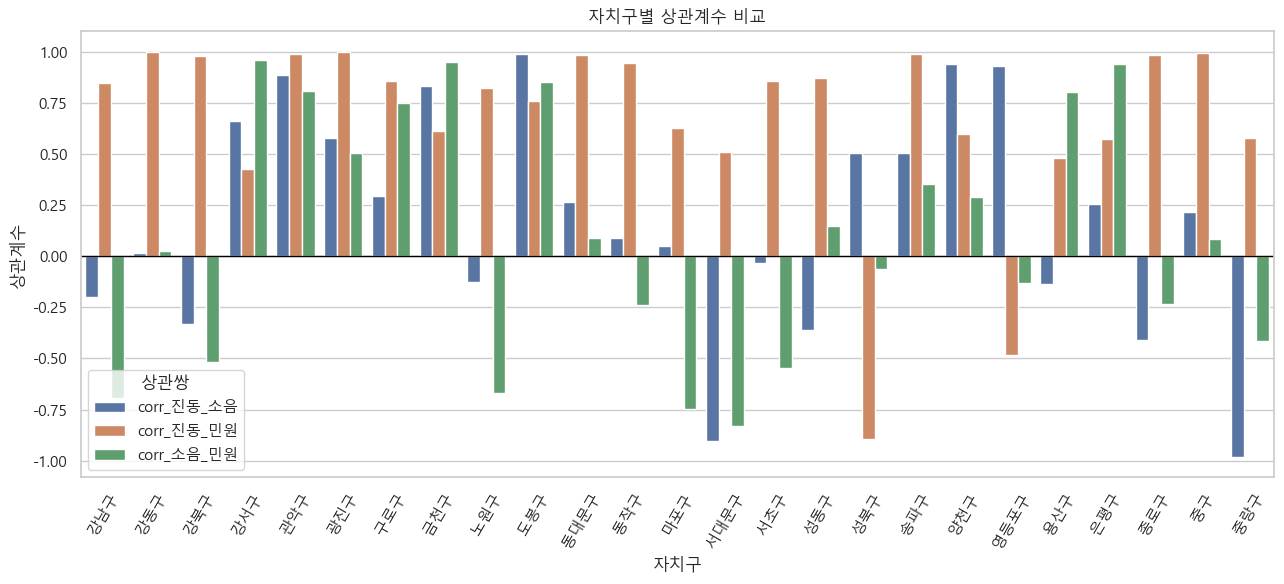

In [25]:
# 상관계수 바차트
m = gu_corr.melt(
    id_vars="자치구",
    value_vars=["corr_진동_소음", "corr_진동_민원", "corr_소음_민원"],
    var_name="상관쌍",
    value_name="상관계수"
)

plt.figure(figsize=(13,6))
sns.barplot(data=m, x="자치구", y="상관계수", hue="상관쌍")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=60)
plt.title("자치구별 상관계수 비교")
plt.tight_layout()
plt.show()

In [26]:
## 해석 코드 C. 진동-소음/민원 상관 읽기
## 무엇을 보나: 진동이 커질수록 소음/민원이 같이 커지는지

# 전체 상관 요약
corr_all = corr_df[["평균진동","평균소음","원민원"]].corr()
display(corr_all)

print("해석 가이드")
print("- corr > 0.5: 강한 양(+) 관계")
print("- 0.2~0.5: 약~중간 양(+) 관계")
print("- ~0: 관계 약함")
print("- 음수: 반대 방향")

,평균진동,평균소음,원민원
평균진동,1.000000,0.012026,0.147282
평균소음,0.012026,1.000000,0.315623
원민원,0.147282,0.315623,1.000000


해석 가이드
- corr > 0.5: 강한 양(+) 관계
- 0.2~0.5: 약~중간 양(+) 관계
- ~0: 관계 약함
- 음수: 반대 방향


In [27]:
# 자치구별 상관 Top/Bottom (3쌍 모두)
print("[진동-소음 상관 높은 구 TOP 10]")
display(gu_corr.sort_values("corr_진동_소음", ascending=False).head(10))

print("[진동-소음 상관 낮은 구 TOP 10]")
display(gu_corr.sort_values("corr_진동_소음", ascending=True).head(10))

print("[진동-민원 상관 높은 구 TOP 10]")
display(gu_corr.sort_values("corr_진동_민원", ascending=False).head(10))

print("[진동-민원 상관 낮은 구 TOP 10]")
display(gu_corr.sort_values("corr_진동_민원", ascending=True).head(10))

print("[소음-민원 상관 높은 구 TOP 10]")
display(gu_corr.sort_values("corr_소음_민원", ascending=False).head(10))

print("[소음-민원 상관 낮은 구 TOP 10]")
display(gu_corr.sort_values("corr_소음_민원", ascending=True).head(10))


[진동-소음 상관 높은 구 TOP 10]


,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
9,도봉구,0.987811,0.758039,0.850320
18,양천구,0.940730,0.594693,0.286779
19,영등포구,0.929772,-0.485240,-0.129271
4,관악구,0.884143,0.989453,0.807139
7,금천구,0.832502,0.612883,0.948000
3,강서구,0.660259,0.425168,0.960496
5,광진구,0.577639,0.996424,0.506601
16,성북구,0.505640,-0.893527,-0.064423
17,송파구,0.503010,0.986101,0.352419
6,구로구,0.296296,0.854549,0.749249


[진동-소음 상관 낮은 구 TOP 10]


,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
24,중랑구,-0.982792,0.575824,-0.414896
13,서대문구,-0.904699,0.510990,-0.828520
22,종로구,-0.411734,0.982780,-0.236254
15,성동구,-0.361041,0.869832,0.146025
2,강북구,-0.332572,0.979568,-0.515443
0,강남구,-0.197805,0.844050,-0.692626
20,용산구,-0.135269,0.481214,0.803453
8,노원구,-0.127682,0.822199,-0.669521
14,서초구,-0.033926,0.856218,-0.545365
1,강동구,0.016503,0.999952,0.026249


[진동-민원 상관 높은 구 TOP 10]


...

,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
16,성북구,0.505640,-0.893527,-0.064423
19,영등포구,0.929772,-0.485240,-0.129271
3,강서구,0.660259,0.425168,0.960496
20,용산구,-0.135269,0.481214,0.803453
13,서대문구,-0.904699,0.510990,-0.828520
21,은평구,0.257133,0.573687,0.939048
24,중랑구,-0.982792,0.575824,-0.414896
18,양천구,0.940730,0.594693,0.286779
7,금천구,0.832502,0.612883,0.948000
12,마포구,0.050559,0.628443,-0.745087


[소음-민원 상관 높은 구 TOP 10]


,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
3,강서구,0.660259,0.425168,0.960496
7,금천구,0.832502,0.612883,0.948000
21,은평구,0.257133,0.573687,0.939048
9,도봉구,0.987811,0.758039,0.850320
4,관악구,0.884143,0.989453,0.807139
20,용산구,-0.135269,0.481214,0.803453
6,구로구,0.296296,0.854549,0.749249
5,광진구,0.577639,0.996424,0.506601
17,송파구,0.503010,0.986101,0.352419
18,양천구,0.940730,0.594693,0.286779


[소음-민원 상관 낮은 구 TOP 10]


,자치구,corr_진동_소음,corr_진동_민원,corr_소음_민원
13,서대문구,-0.904699,0.510990,-0.828520
12,마포구,0.050559,0.628443,-0.745087
0,강남구,-0.197805,0.844050,-0.692626
8,노원구,-0.127682,0.822199,-0.669521
14,서초구,-0.033926,0.856218,-0.545365
2,강북구,-0.332572,0.979568,-0.515443
24,중랑구,-0.982792,0.575824,-0.414896
11,동작구,0.091092,0.945041,-0.239508
22,종로구,-0.411734,0.982780,-0.236254
19,영등포구,0.929772,-0.485240,-0.129271


In [28]:
# 상관 유형 라벨링 (3쌍 모두)
def corr_label(x):
    if pd.isna(x): return "판단불가"
    if x >= 0.5: return "강한양의관계"
    if x >= 0.2: return "중간양의관계"
    if x > -0.2: return "약한/무관"
    return "음의관계"

gu_corr["진동-소음_해석"] = gu_corr["corr_진동_소음"].apply(corr_label)
gu_corr["진동-민원_해석"] = gu_corr["corr_진동_민원"].apply(corr_label)
gu_corr["소음-민원_해석"] = gu_corr["corr_소음_민원"].apply(corr_label)

display(
    gu_corr[[
        "자치구",
        "corr_진동_소음","진동-소음_해석",
        "corr_진동_민원","진동-민원_해석",
        "corr_소음_민원","소음-민원_해석"
    ]]
)


,자치구,corr_진동_소음,진동-소음_해석,corr_진동_민원,진동-민원_해석,corr_소음_민원,소음-민원_해석
0,강남구,-0.197805,약한/무관,0.844050,강한양의관계,-0.692626,음의관계
1,강동구,0.016503,약한/무관,0.999952,강한양의관계,0.026249,약한/무관
2,강북구,-0.332572,음의관계,0.979568,강한양의관계,-0.515443,음의관계
3,강서구,0.660259,강한양의관계,0.425168,중간양의관계,0.960496,강한양의관계
4,관악구,0.884143,강한양의관계,0.989453,강한양의관계,0.807139,강한양의관계
5,광진구,0.577639,강한양의관계,0.996424,강한양의관계,0.506601,강한양의관계
6,구로구,0.296296,중간양의관계,0.854549,강한양의관계,0.749249,강한양의관계
7,금천구,0.832502,강한양의관계,0.612883,강한양의관계,0.948000,강한양의관계
8,노원구,-0.127682,약한/무관,0.822199,강한양의관계,-0.669521,음의관계
9,도봉구,0.987811,강한양의관계,0.758039,강한양의관계,0.850320,강한양의관계


In [29]:
# 자치구별 "주요 연동축" 자동 분류
# 절대값 기준으로 가장 강한 상관쌍을 뽑아 해석 포인트 생성
pairs = ["corr_진동_소음", "corr_진동_민원", "corr_소음_민원"]

tmp = gu_corr.copy()
tmp["주요연동축"] = tmp[pairs].abs().idxmax(axis=1)
tmp["주요연동강도"] = tmp.lookup(tmp.index, tmp["주요연동축"]) if hasattr(tmp, "lookup") else [
    tmp.loc[i, c] for i, c in zip(tmp.index, tmp["주요연동축"])
]

display(tmp[["자치구","주요연동축","주요연동강도"]].sort_values("주요연동강도", ascending=False))


,자치구,주요연동축,주요연동강도
1,강동구,corr_진동_민원,0.999952
5,광진구,corr_진동_민원,0.996424
23,중구,corr_진동_민원,0.991426
4,관악구,corr_진동_민원,0.989453
9,도봉구,corr_진동_소음,0.987811
17,송파구,corr_진동_민원,0.986101
10,동대문구,corr_진동_민원,0.983612
22,종로구,corr_진동_민원,0.982780
2,강북구,corr_진동_민원,0.979568
3,강서구,corr_소음_민원,0.960496


## STEP 6. 민원: 원값 vs 인구보정값 비교
- 목적: 인구 큰 자치구의 민원 건수 착시를 분리

In [30]:
# 인구 데이터 로드 + 결합 후 인구보정 민원 계산
population = pd.read_sql(
    """
    SELECT 자치구,
           `2022_행정구역(A)_인구 (명)` AS 인구_2022,
           `2023_행정구역(A)_인구 (명)` AS 인구_2023,
           `2024_행정구역(A)_인구 (명)` AS 인구_2024
    FROM garbage_collection_status
    """,
    engine
)
population = population[population["자치구"] != "소계"].copy()

compl = noise_com2[["자치구", "소음진동민원_2022", "소음진동민원_2023", "소음진동민원_2024"]].merge(
    population, on="자치구", how="left"
)

compl["만명당민원_2022"] = compl["소음진동민원_2022"] / compl["인구_2022"] * 10000
compl["만명당민원_2023"] = compl["소음진동민원_2023"] / compl["인구_2023"] * 10000
compl["만명당민원_2024"] = compl["소음진동민원_2024"] / compl["인구_2024"] * 10000

display(compl.head())


,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당민원_2022,만명당민원_2023,만명당민원_2024
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900
4,광진구,1892,1374,1329,351252,351180,348652,53.864462,39.125235,38.118238


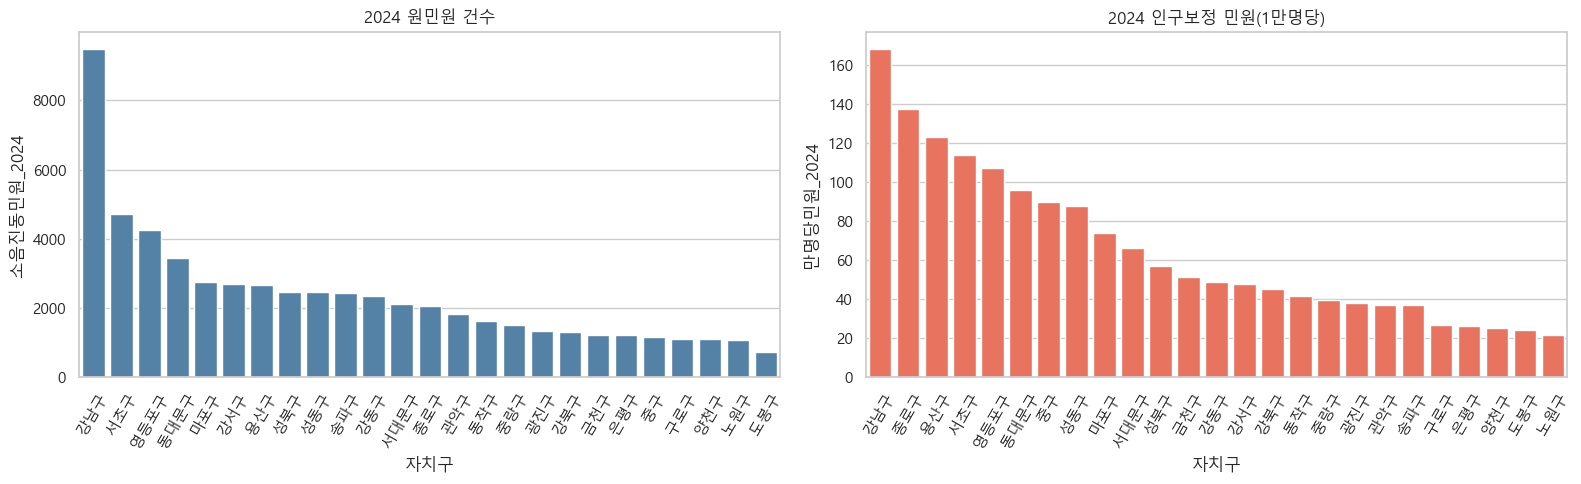

In [31]:
# 2024 기준 원민원 vs 인구보정민원 바차트
tmp_raw = compl[["자치구", "소음진동민원_2024"]].sort_values("소음진동민원_2024", ascending=False)
tmp_adj = compl[["자치구", "만명당민원_2024"]].sort_values("만명당민원_2024", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16,5))

sns.barplot(data=tmp_raw, x="자치구", y="소음진동민원_2024", ax=ax[0], color="steelblue")
ax[0].set_title("2024 원민원 건수")
ax[0].tick_params(axis="x", rotation=60)

sns.barplot(data=tmp_adj, x="자치구", y="만명당민원_2024", ax=ax[1], color="tomato")
ax[1].set_title("2024 인구보정 민원(1만명당)")
ax[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


In [32]:
# D-해석 1) 순위 비교표
rank_cmp = compl[["자치구", "소음진동민원_2024", "만명당민원_2024"]].copy()
rank_cmp["원민원순위"] = rank_cmp["소음진동민원_2024"].rank(ascending=False, method="min")
rank_cmp["보정민원순위"] = rank_cmp["만명당민원_2024"].rank(ascending=False, method="min")
rank_cmp["순위차(원-보정)"] = rank_cmp["원민원순위"] - rank_cmp["보정민원순위"]

print("[원민원 기준 높지만 보정 후 내려가는 구 TOP 10]")
display(rank_cmp.sort_values("순위차(원-보정)", ascending=False).head(10))

print("[원민원 기준 낮지만 보정 후 올라가는 구 TOP 10]")
display(rank_cmp.sort_values("순위차(원-보정)", ascending=True).head(10))


[원민원 기준 높지만 보정 후 내려가는 구 TOP 10]


,자치구,소음진동민원_2024,만명당민원_2024,원민원순위,보정민원순위,순위차(원-보정)
1,중구,1180,89.929428,21.0,7.0,14.0
0,종로구,2057,137.492647,13.0,2.0,11.0
17,금천구,1237,51.742168,19.0,12.0,7.0
2,용산구,2673,123.069698,7.0,3.0,4.0
8,강북구,1311,45.304692,18.0,15.0,3.0
12,서대문구,2109,66.191286,12.0,10.0,2.0
16,구로구,1114,27.044349,22.0,21.0,1.0
9,도봉구,740,24.180478,25.0,24.0,1.0
3,성동구,2477,88.058900,9.0,8.0,1.0
22,강남구,9494,168.567954,1.0,1.0,0.0


[원민원 기준 낮지만 보정 후 올라가는 구 TOP 10]


,자치구,소음진동민원_2024,만명당민원_2024,원민원순위,보정민원순위,순위차(원-보정)
23,송파구,2430,37.025186,10.0,20.0,-10.0
15,강서구,2685,47.759314,6.0,14.0,-8.0
20,관악구,1842,37.165570,14.0,19.0,-5.0
13,마포구,2756,73.937947,5.0,9.0,-4.0
7,성북구,2478,56.960672,8.0,11.0,-3.0
18,영등포구,4268,107.459470,3.0,5.0,-2.0
11,은평구,1234,26.517675,20.0,22.0,-2.0
5,동대문구,3447,96.123011,4.0,6.0,-2.0
21,서초구,4717,114.192062,2.0,4.0,-2.0
24,강동구,2361,49.036916,11.0,13.0,-2.0


In [33]:
# 착시지수(원민원 z - 보정민원 z)
# 값이 클수록 "원민원은 높지만 보정하면 상대적으로 덜 높은" 착시 가능
def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / (s.std() if s.std() != 0 else 1)

rank_cmp["착시지수"] = zscore(rank_cmp["소음진동민원_2024"]) - zscore(rank_cmp["만명당민원_2024"])

print("[착시지수 높은 구 TOP 10]")
display(rank_cmp.sort_values("착시지수", ascending=False).head(10))


[착시지수 높은 구 TOP 10]


,자치구,소음진동민원_2024,만명당민원_2024,원민원순위,보정민원순위,순위차(원-보정),착시지수
22,강남구,9494,168.567954,1.0,1.0,0.0,1.403584
23,송파구,2430,37.025186,10.0,20.0,-10.0,0.741458
15,강서구,2685,47.759314,6.0,14.0,-8.0,0.615821
20,관악구,1842,37.165570,14.0,19.0,-5.0,0.409286
24,강동구,2361,49.036916,11.0,13.0,-2.0,0.402802
10,노원구,1078,21.709710,24.0,25.0,-1.0,0.368378
11,은평구,1234,26.517675,20.0,22.0,-2.0,0.335457
14,양천구,1104,25.417232,23.0,23.0,0.0,0.290285
7,성북구,2478,56.960672,8.0,11.0,-3.0,0.270240
16,구로구,1114,27.044349,22.0,21.0,1.0,0.255225


In [34]:
top_noise_gu = noise_gu_summary.sort_values("평균소음", ascending=False).head(3)["자치구"].tolist()
top_corr_gu = gu_corr.sort_values("corr_진동_소음", ascending=False).head(3)["자치구"].tolist()
top_bias_gu = rank_cmp.sort_values("착시지수", ascending=False).head(3)["자치구"].tolist()

print(f"1) 평균 소음이 높은 자치구는 {', '.join(top_noise_gu)} 입니다.")
print(f"2) 진동-소음 연동성이 큰 자치구는 {', '.join(top_corr_gu)} 입니다.")
print(f"3) 민원 원값 대비 인구보정 시 착시 가능성이 큰 자치구는 {', '.join(top_bias_gu)} 입니다.")


1) 평균 소음이 높은 자치구는 은평구, 성동구, 강서구 입니다.
2) 진동-소음 연동성이 큰 자치구는 도봉구, 양천구, 영등포구 입니다.
3) 민원 원값 대비 인구보정 시 착시 가능성이 큰 자치구는 강남구, 송파구, 강서구 입니다.


In [35]:
# 1) 이상치 후보 추출 (소음)
q1, q3 = noise_long["소음값"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr

outliers = noise_long[noise_long["소음값"] > upper].copy()
outliers = outliers.sort_values(["연도","월","자치구","지역"])
display(outliers[["자치구","지역","연도","월","소음값"]].head(50))

print("이상치 개수:", len(outliers))
print("연도-월 분포:")
display(outliers.groupby(["연도","월"]).size().reset_index(name="건수").sort_values("건수", ascending=False))


,자치구,지역,연도,월,소음값
2453,강남구,main_street,2023,7,149.035011
2456,강남구,traditional_markets,2023,7,79.464913
2465,강동구,main_street,2023,7,336.269203
2467,강동구,residential_area,2023,7,138.999154
2379,강북구,roads_and_parks,2023,7,160.563229
2363,광진구,traditional_markets,2023,7,199.956213
2426,금천구,industrial_area,2023,7,95.661179
2388,노원구,industrial_area,2023,7,79.975235
2389,노원구,residential_area,2023,7,83.881239
2390,노원구,roads_and_parks,2023,7,74.632541


이상치 개수: 23
연도-월 분포:


,연도,월,건수
0,2023,7,23


In [36]:
# 2) 특정 월(예: 2023-07)만 집중 점검
chk = noise_long[(noise_long["연도"]==2023) & (noise_long["월"]==7)].copy()

print("2023-07 전체 통계")
display(chk["소음값"].describe())

print("자치구별 평균")
display(chk.groupby("자치구", as_index=False)["소음값"].mean().sort_values("소음값", ascending=False).head(20))


2023-07 전체 통계


count    129.000000
mean      72.718375
std       61.517282
min       39.750203
25%       49.936117
50%       56.103016
75%       64.692498
max      476.454616
Name: 소음값, dtype: float64

자치구별 평균


,자치구,소음값
20,용산구,140.441034
15,성동구,133.162280
12,마포구,107.921707
1,강동구,103.846323
22,종로구,84.488369
5,광진구,81.392960
14,서초구,74.905335
0,강남구,74.725137
2,강북구,73.682035
8,노원구,68.086455


In [37]:
# 3) 전후월 비교 (6월/7월/8월) -> 진짜 이벤트면 7월만 튀고 전후도 일부 연동 흔적이 보이는지
cmp = noise_long[
    (noise_long["연도"]==2023) & (noise_long["월"].isin([6,7,8]))
].groupby(["자치구","월"], as_index=False)["소음값"].mean()

pivot = cmp.pivot(index="자치구", columns="월", values="소음값").reset_index()
pivot["7월-6월"] = pivot[7] - pivot[6]
pivot["7월-8월"] = pivot[7] - pivot[8]

display(pivot.sort_values("7월-6월", ascending=False).head(15))


월,자치구,6,7,8,7월-6월,7월-8월
20,용산구,50.610646,140.441034,52.376209,89.830388,88.064825
15,성동구,54.770954,133.162280,57.226490,78.391326,75.935790
12,마포구,51.649976,107.921707,53.734355,56.271732,54.187352
1,강동구,52.023680,103.846323,52.820162,51.822643,51.026161
22,종로구,50.390631,84.488369,52.097728,34.097739,32.390642
5,광진구,51.686078,81.392960,50.719036,29.706882,30.673925
2,강북구,50.382435,73.682035,51.093442,23.299599,22.588593
14,서초구,52.709033,74.905335,54.403626,22.196302,20.501709
0,강남구,54.385277,74.725137,56.499264,20.339860,18.225872
8,노원구,49.140684,68.086455,51.257465,18.945771,16.828990


In [38]:
# 4) 같은 시점 진동/민원 동시 확인
# 7월 소음이 튄 구에서 진동/민원도 같이 튀면 '실제 사건' 가능성↑
noise_july_top = pivot.sort_values("7월-6월", ascending=False).head(10)["자치구"]

vib_chk = vibration_long[
    (vibration_long["연도"]==2023) & (vibration_long["월"].isin([6,7,8])) &
    (vibration_long["자치구"].isin(noise_july_top))
].groupby(["자치구","월"], as_index=False)["진동값"].mean()

display(vib_chk.sort_values(["자치구","월"]))


,자치구,월,진동값
0,강남구,6,0.374639
1,강남구,7,0.374262
2,강남구,8,0.374754
3,강동구,6,0.362953
4,강동구,7,0.362167
5,강동구,8,0.363157
6,강북구,6,0.369340
7,강북구,7,0.371205
8,강북구,8,0.369897
9,광진구,6,0.366930


In [39]:
# [AUTO LABEL] 소음 이상치: 실제이슈 후보 vs 장비/집계오류 후보
# 전제: noise_long(자치구, 지역, 연도, 월, 소음값), vibration_long(자치구, 연도, 월, 진동값) 존재

import pandas as pd
import numpy as np

# -----------------------------
# 0) 기준 테이블 만들기 (구-월 평균 소음)
# -----------------------------
gu_month_noise = (
    noise_long.groupby(["자치구", "연도", "월"], as_index=False)["소음값"]
    .mean()
    .rename(columns={"소음값":"구월평균소음"})
)

# 전후월 대비 상승폭 계산
tmp = gu_month_noise.copy()
tmp_prev = tmp.copy(); tmp_prev["월"] = tmp_prev["월"] + 1
tmp_next = tmp.copy(); tmp_next["월"] = tmp_next["월"] - 1

tmp = tmp.merge(
    tmp_prev[["자치구","연도","월","구월평균소음"]].rename(columns={"구월평균소음":"전월평균소음"}),
    on=["자치구","연도","월"], how="left"
).merge(
    tmp_next[["자치구","연도","월","구월평균소음"]].rename(columns={"구월평균소음":"익월평균소음"}),
    on=["자치구","연도","월"], how="left"
)

tmp["상승_전월대비"] = tmp["구월평균소음"] - tmp["전월평균소음"]
tmp["상승_익월대비"] = tmp["구월평균소음"] - tmp["익월평균소음"]

# IQR 기준 급등 플래그 (구-월 평균 기준)
q1, q3 = tmp["구월평균소음"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
tmp["급등플래그"] = tmp["구월평균소음"] > upper

# -----------------------------
# 1) 월별 동시성 점수 (같은 연월에 급등한 구가 많은지)
# -----------------------------
month_conc = (
    tmp[tmp["급등플래그"]]
    .groupby(["연도","월"], as_index=False)
    .size()
    .rename(columns={"size":"동시급등구수"})
)
tmp = tmp.merge(month_conc, on=["연도","월"], how="left")
tmp["동시급등구수"] = tmp["동시급등구수"].fillna(0)

# -----------------------------
# 2) 진동 동반 점수 (해당 구/연월에 진동도 같이 상승했는지)
# -----------------------------
gu_month_vib = (
    vibration_long.groupby(["자치구","연도","월"], as_index=False)["진동값"]
    .mean()
    .rename(columns={"진동값":"구월평균진동"})
)

v = gu_month_vib.copy()
v_prev = v.copy(); v_prev["월"] = v_prev["월"] + 1
v_next = v.copy(); v_next["월"] = v_next["월"] - 1

v = v.merge(
    v_prev[["자치구","연도","월","구월평균진동"]].rename(columns={"구월평균진동":"전월진동"}),
    on=["자치구","연도","월"], how="left"
).merge(
    v_next[["자치구","연도","월","구월평균진동"]].rename(columns={"구월평균진동":"익월진동"}),
    on=["자치구","연도","월"], how="left"
)

v["진동상승_전월대비"] = v["구월평균진동"] - v["전월진동"]
v["진동상승_익월대비"] = v["구월평균진동"] - v["익월진동"]

tmp = tmp.merge(
    v[["자치구","연도","월","구월평균진동","진동상승_전월대비","진동상승_익월대비"]],
    on=["자치구","연도","월"], how="left"
)

# -----------------------------
# 3) 센서(지역) 집중도 (특정 지역 1~2개만 튀는지)
# -----------------------------
# 구-연도-월 내부에서 지역별 소음값의 이상 집중 확인
region_stats = (
    noise_long.groupby(["자치구","연도","월","지역"], as_index=False)["소음값"]
    .mean()
)
# 지역별 z-score (구-연월 내부)
region_stats["지역z"] = region_stats.groupby(["자치구","연도","월"])["소음값"].transform(
    lambda s: (s - s.mean()) / (s.std() if s.std() not in [0, np.nan] and pd.notna(s.std()) else 1)
)

# 구-연월별로 지역 이상치 수/최대 z
region_agg = region_stats.groupby(["자치구","연도","월"], as_index=False).agg(
    지역최대z=("지역z","max"),
    지역이상치수=("지역z", lambda x: (x > 2.5).sum()),
    지역개수=("지역","nunique")
)

tmp = tmp.merge(region_agg, on=["자치구","연도","월"], how="left")

# -----------------------------
# 4) 자동 라벨링 규칙
# -----------------------------
# 규칙 직관:
# - 동시급등구수 많고(광역 동시), 진동 동반 약하면 -> 집계/시스템 오류 의심
# - 동시급등 적고, 진동 동반 강하면 -> 실제 이슈 후보
# - 특정 지역만 튀면 -> 장비(센서) 이상 후보
def label_row(r):
    if not r["급등플래그"]:
        return "정상범위"

    vib_support = (
        (pd.notna(r["진동상승_전월대비"]) and r["진동상승_전월대비"] > 0) or
        (pd.notna(r["진동상승_익월대비"]) and r["진동상승_익월대비"] > 0)
    )

    # 지역 집중 (센서 1~2개만 강한 스파이크)
    sensor_like = (pd.notna(r["지역이상치수"]) and r["지역이상치수"] <= 2 and pd.notna(r["지역최대z"]) and r["지역최대z"] >= 3.0)

    if r["동시급등구수"] >= 5 and not vib_support:
        return "집계/시스템오류의심"
    if sensor_like and not vib_support:
        return "장비오류의심"
    if vib_support and r["동시급등구수"] <= 3:
        return "실제이슈후보"
    if vib_support and r["동시급등구수"] >= 4:
        return "광역이슈후보"
    return "검토필요"

tmp["자동판정"] = tmp.apply(label_row, axis=1)

# -----------------------------
# 5) 결과 보기
# -----------------------------
result_cols = [
    "자치구","연도","월","구월평균소음","전월평균소음","익월평균소음",
    "상승_전월대비","상승_익월대비","동시급등구수",
    "구월평균진동","진동상승_전월대비","진동상승_익월대비",
    "지역개수","지역이상치수","지역최대z","급등플래그","자동판정"
]

result = tmp[result_cols].copy().sort_values(["연도","월","자치구"])
display(result.head(20))

print("\n자동판정 분포")
display(result["자동판정"].value_counts())

print("\n급등 케이스만")
display(result[result["급등플래그"]].sort_values(["연도","월","구월평균소음"], ascending=[True,True,False]).head(50))


,자치구,연도,월,구월평균소음,전월평균소음,익월평균소음,상승_전월대비,상승_익월대비,동시급등구수,구월평균진동,진동상승_전월대비,진동상승_익월대비,지역개수,지역이상치수,지역최대z,급등플래그,자동판정
0,강남구,2022,1,54.159004,NaN,54.340269,NaN,-0.181265,0.0,0.379501,NaN,-0.000182,6,0,1.369831,False,정상범위
36,강동구,2022,1,54.570126,NaN,55.737533,NaN,-1.167406,0.0,0.378992,NaN,0.009801,7,0,1.569572,False,정상범위
72,강북구,2022,1,50.333719,NaN,50.528745,NaN,-0.195026,0.0,0.374764,NaN,0.000622,5,0,1.675700,False,정상범위
108,강서구,2022,1,56.320527,NaN,56.664509,NaN,-0.343982,0.0,0.374604,NaN,0.000201,6,0,1.556091,False,정상범위
144,관악구,2022,1,49.865235,NaN,49.672080,NaN,0.193156,0.0,0.376958,NaN,0.000241,6,0,1.695816,False,정상범위
180,광진구,2022,1,54.938421,NaN,55.242548,NaN,-0.304127,0.0,0.377408,NaN,0.000805,5,0,1.438305,False,정상범위
216,구로구,2022,1,50.387660,NaN,50.367295,NaN,0.020364,0.0,0.381053,NaN,0.000407,5,0,1.683987,False,정상범위
252,금천구,2022,1,48.917808,NaN,49.019272,NaN,-0.101464,0.0,0.376859,NaN,0.000398,5,0,1.432143,False,정상범위
288,노원구,2022,1,48.174006,NaN,48.300530,NaN,-0.126524,0.0,0.373093,NaN,0.000107,5,0,1.107645,False,정상범위
324,도봉구,2022,1,51.513611,NaN,51.502322,NaN,0.011290,0.0,0.377869,NaN,0.000912,6,0,1.273956,False,정상범위



자동판정 분포


자동판정
정상범위          885
집계/시스템오류의심      8
광역이슈후보          7
Name: count, dtype: int64


급등 케이스만


,자치구,연도,월,구월평균소음,전월평균소음,익월평균소음,상승_전월대비,상승_익월대비,동시급등구수,구월평균진동,진동상승_전월대비,진동상승_익월대비,지역개수,지역이상치수,지역최대z,급등플래그,자동판정
738,용산구,2023,7,140.441034,50.610646,52.376209,89.830388,88.064825,15.0,0.368510,-0.000167,-0.001546,4,0,1.499057,True,집계/시스템오류의심
558,성동구,2023,7,133.162280,54.770954,57.226490,78.391326,75.935790,15.0,0.370596,0.000915,0.001767,6,0,2.038456,True,광역이슈후보
450,마포구,2023,7,107.921707,51.649976,53.734355,56.271732,54.187352,15.0,0.373498,-0.000264,-0.000121,6,0,1.833754,True,집계/시스템오류의심
54,강동구,2023,7,103.846323,52.023680,52.820162,51.822643,51.026161,15.0,0.362167,-0.000786,-0.000990,7,0,2.154719,True,집계/시스템오류의심
810,종로구,2023,7,84.488369,50.390631,52.097728,34.097739,32.390642,15.0,0.368125,-0.000641,0.001857,4,0,1.436270,True,광역이슈후보
198,광진구,2023,7,81.392960,51.686078,50.719036,29.706882,30.673925,15.0,0.366996,0.000066,-0.000063,5,0,1.775792,True,광역이슈후보
522,서초구,2023,7,74.905335,52.709033,54.403626,22.196302,20.501709,15.0,0.367319,-0.002171,-0.001166,6,0,1.763652,True,집계/시스템오류의심
18,강남구,2023,7,74.725137,54.385277,56.499264,20.339860,18.225872,15.0,0.374262,-0.000377,-0.000492,6,0,1.955381,True,집계/시스템오류의심
90,강북구,2023,7,73.682035,50.382435,51.093442,23.299599,22.588593,15.0,0.371205,0.001865,0.001308,5,0,1.787625,True,광역이슈후보
306,노원구,2023,7,68.086455,49.140684,51.257465,18.945771,16.828990,15.0,0.373427,0.001717,-0.000460,5,0,0.970058,True,광역이슈후보


In [40]:
# 1) 오류의심 플래그
df2 = noise_long.copy()
df2["오류의심"] = ((df2["연도"] == 2023) & (df2["월"] == 7)).astype(int)  # 필요시 자치구 조건 추가


In [41]:
# 2) 윈저라이즈(상위 99%) 적용값 생성
upper_99 = df2["소음값"].quantile(0.99)
df2["소음값_winsor"] = df2["소음값"].clip(upper=upper_99)
print("상한(99%):", upper_99)


상한(99%): 69.28630187659522


In [42]:
# 3) 3개 버전 집계 비교: 원본 / winsor / 2023-07 제외
orig = df2.groupby(["자치구","연도","월"], as_index=False)["소음값"].mean().rename(columns={"소음값":"평균소음_orig"})
wins = df2.groupby(["자치구","연도","월"], as_index=False)["소음값_winsor"].mean().rename(columns={"소음값_winsor":"평균소음_winsor"})
drop = df2[~((df2["연도"]==2023)&(df2["월"]==7))].groupby(["자치구","연도","월"], as_index=False)["소음값"].mean().rename(columns={"소음값":"평균소음_drop202307"})

cmp = orig.merge(wins, on=["자치구","연도","월"], how="left").merge(drop, on=["자치구","연도","월"], how="left")
display(cmp.head())


,자치구,연도,월,평균소음_orig,평균소음_winsor,평균소음_drop202307
0,강남구,2022,1,54.159004,54.159004,54.159004
1,강남구,2022,2,54.340269,54.340269,54.340269
2,강남구,2022,3,52.879348,52.879348,52.879348
3,강남구,2022,4,52.624845,52.624845,52.624845
4,강남구,2022,5,53.053915,53.053915,53.053915


In [43]:
# 4) 영향도 확인 (연도평균 기준)
year_cmp = cmp.groupby("연도", as_index=False)[["평균소음_orig","평균소음_winsor","평균소음_drop202307"]].mean()
display(year_cmp)


,연도,평균소음_orig,평균소음_winsor,평균소음_drop202307
0,2022,52.019327,52.015728,52.019327
1,2023,53.316842,52.036241,51.594461
2,2024,51.171802,51.171339,51.171802


In [44]:
# 진동 이상 의심월 플래그
vib_df = vibration_long.copy()
vib_df["이상의심월"] = (
    ((vib_df["연도"] == 2022) & (vib_df["월"] == 12)) |
    ((vib_df["연도"] == 2023) & (vib_df["월"] == 10))
)

# 원본 vs 의심월 제외 월평균 비교
orig = vib_df.groupby(["자치구","연도","월"], as_index=False)["진동값"].mean().rename(columns={"진동값":"진동_원본"})
drop = vib_df[~vib_df["이상의심월"]].groupby(["자치구","연도","월"], as_index=False)["진동값"].mean().rename(columns={"진동값":"진동_의심월제외"})

cmp_vib = orig.merge(drop, on=["자치구","연도","월"], how="left")
display(cmp_vib.head())


,자치구,연도,월,진동_원본,진동_의심월제외
0,강남구,2022,1,0.379501,0.379501
1,강남구,2022,2,0.379683,0.379683
2,강남구,2022,3,0.376577,0.376577
3,강남구,2022,4,0.375577,0.375577
4,강남구,2022,5,0.375159,0.375159


In [45]:
# 연도 평균 영향도 확인
year_cmp_vib = cmp_vib.groupby("연도", as_index=False)[["진동_원본","진동_의심월제외"]].mean()
year_cmp_vib["차이"] = year_cmp_vib["진동_원본"] - year_cmp_vib["진동_의심월제외"]
display(year_cmp_vib)


,연도,진동_원본,진동_의심월제외,차이
0,2022,1.408944,0.372837,1.036108
1,2023,0.543543,0.371387,0.172156
2,2024,0.370194,0.370194,0.000000


### 점수 재산정

## Step 1. 이상치 월 정의 및 처리 원칙

### 배경
- 소음/진동 월별 그래프에서 특정 월에 다수 자치구가 동시에 급등하는 패턴이 관찰되었습니다.
- 이 패턴은 실제 환경 이벤트일 수도 있고, 집계/센서/전처리 이슈일 수도 있어 단정할 수 없습니다.

### 처리 원칙
1. 원본 데이터는 보존합니다.
2. 이상치 월은 결측(`NaN`)으로 마스킹한 뒤 보간본을 만듭니다.
3. 최종 결론은 원본/보간본을 함께 비교해 민감도를 확인합니다.

### 이번 분석에서 사용할 이상치 월
- 소음: 2023년 7월
- 진동: 2022년 12월, 2023년 10월

In [46]:
noise_anomaly = {(2023, 7)}
vib_anomaly = {(2022, 12), (2023, 10)}

## Step 2. 보간 함수 및 점수 함수 준비

### 왜 필요한가
- 보간 방식과 점수화 방식을 고정해야 원본/보간 비교가 일관됩니다.
- 점수화는 기존 분석과 동일한 스케일(1~8)을 유지해야 비교가 가능합니다.

### 함수 설명
- `to_1_8_stress_score`: Min-Max 기반 1~8 환산
- `zscore`: 평균/표준편차 기반 표준화(대표지표 결합 시 사용)


In [47]:
import pandas as pd
import numpy as np

def to_1_8_stress_score(s):
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx):
        return pd.Series(np.nan, index=s.index)
    if mx == mn:
        return pd.Series(4.5, index=s.index)
    return 1 + (s - mn) / (mx - mn) * 7

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    std = s.std()
    if std == 0 or pd.isna(std):
        return pd.Series(0, index=s.index)
    return (s - s.mean()) / std


## Step 3. 소음 데이터 보간본 생성

### 보간 단위
- `자치구 × 지역 × 월` 그룹에서 연도축(2022→2024) 보간

### 근거
- 동일 월/동일 지역의 연도 간 값은 서로 비교 가능한 시계열로 볼 수 있습니다.
- 3개년 데이터이므로 2023 값은 2022/2024 사이 선형보간이 됩니다.
- 경계값(2022, 2024)은 `bfill/ffill`로 보완합니다.


In [48]:
# noise_long 필요 컬럼: 자치구, 지역, 연도, 월, 소음값
noise_work = noise_long.copy()

noise_work["is_anomaly"] = noise_work.apply(
    lambda r: (int(r["연도"]), int(r["월"])) in noise_anomaly, axis=1
)

# 이상치 월은 결측 처리 (원본 소음값은 유지)
noise_work["소음값_clean"] = noise_work["소음값"].where(~noise_work["is_anomaly"], np.nan)

noise_work = noise_work.sort_values(["자치구", "지역", "월", "연도"])
noise_work["소음값_interp"] = (
    noise_work.groupby(["자치구", "지역", "월"])["소음값_clean"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both").bfill().ffill())
)

## Step 4. 진동 데이터 보간본 생성

### 보간 단위
- `자치구 × 축(X/Y/Z) × 월` 그룹에서 연도축 보간

### 근거
- 진동은 축별 분포가 다를 수 있어 축을 분리해서 보간해야 왜곡이 줄어듭니다.
- 소음과 동일하게 원본은 보존하고 보간값 컬럼을 별도로 생성합니다.


In [49]:
# vibration_long 필요 컬럼: 자치구, 축, 연도, 월, 진동값
vib_work = vibration_long.copy()

vib_work["is_anomaly"] = vib_work.apply(
    lambda r: (int(r["연도"]), int(r["월"])) in vib_anomaly, axis=1
)

vib_work["진동값_clean"] = vib_work["진동값"].where(~vib_work["is_anomaly"], np.nan)

vib_work = vib_work.sort_values(["자치구", "축", "월", "연도"])
vib_work["진동값_interp"] = (
    vib_work.groupby(["자치구", "축", "월"])["진동값_clean"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both").bfill().ffill())
)


## Step 5. 원본 vs 보간본 기초 통계 비교

### 왜 먼저 통계를 보나
- 보간이 데이터 분포를 과도하게 바꾸지 않았는지 확인해야 합니다.
- 연도별 `mean/median/std/p95/max` 비교로 변형 강도를 확인합니다.

### 해석 포인트
- 평균/중앙값 차이가 작으면 전반 영향이 제한적
- max, p95 차이가 크면 극단값 영향이 컸다는 신호


In [50]:
def yearly_stats(df, value_col, tag):
    g = df.groupby("연도")[value_col]
    return pd.DataFrame({
        "연도": g.mean().index,
        f"{tag}_mean": g.mean().values,
        f"{tag}_median": g.median().values,
        f"{tag}_std": g.std().values,
        f"{tag}_p95": g.quantile(0.95).values,
        f"{tag}_max": g.max().values
    })

noise_stats = yearly_stats(noise_work, "소음값", "noise_orig").merge(
    yearly_stats(noise_work, "소음값_interp", "noise_interp"), on="연도"
)
vib_stats = yearly_stats(vib_work, "진동값", "vib_orig").merge(
    yearly_stats(vib_work, "진동값_interp", "vib_interp"), on="연도"
)

display(noise_stats)
display(vib_stats)


,연도,noise_orig_mean,noise_orig_median,noise_orig_std,noise_orig_p95,noise_orig_max,noise_interp_mean,noise_interp_median,noise_interp_std,noise_interp_p95,noise_interp_max
0,2022,52.087954,50.209353,7.012855,65.796799,70.954269,52.096561,50.217577,7.008159,65.791090,70.954269
1,2023,53.390082,50.472159,19.748393,65.058705,476.454616,51.670583,50.167962,6.731788,64.433750,70.242584
2,2024,51.193639,49.536946,6.730490,64.009825,69.627422,51.194630,49.575246,6.684159,63.984689,69.627422


,연도,vib_orig_mean,vib_orig_median,vib_orig_std,vib_orig_p95,vib_orig_max,vib_interp_mean,vib_interp_median,vib_interp_std,vib_interp_p95,vib_interp_max
0,2022,1.408944,0.062792,5.783551,1.905140,37.054933,0.372906,0.060362,0.465339,1.041156,1.056603
1,2023,0.543543,0.063481,1.139862,1.040071,6.824648,0.371333,0.060815,0.462651,1.037121,1.048404
2,2024,0.370194,0.061022,0.460918,1.036617,1.050543,0.370194,0.061022,0.460918,1.036617,1.050543


## Step 6. 소음 점수 재산출 (원본/보간)

### 점수화 방식
- 자치구-연도 평균 소음을 만든 뒤
- 연도별 분포 기준으로 1~8 점수화

### 근거
- 기존 점수 체계와 동일한 방식으로 계산해야 비교 가능성이 유지됩니다.


In [51]:
noise_year_orig = (
    noise_work.groupby(["자치구", "연도"], as_index=False)["소음값"]
    .mean().rename(columns={"소음값":"평균소음_orig"})
)
noise_year_interp = (
    noise_work.groupby(["자치구", "연도"], as_index=False)["소음값_interp"]
    .mean().rename(columns={"소음값_interp":"평균소음_interp"})
)

noise_score_orig = noise_year_orig.copy()
noise_score_orig["소음스트레스점수_orig"] = (
    noise_score_orig.groupby("연도")["평균소음_orig"]
    .transform(lambda x: to_1_8_stress_score(x)).round(2)
)

noise_score_interp = noise_year_interp.copy()
noise_score_interp["소음스트레스점수_interp"] = (
    noise_score_interp.groupby("연도")["평균소음_interp"]
    .transform(lambda x: to_1_8_stress_score(x)).round(2)
)

noise_score_cmp = noise_score_orig.merge(
    noise_score_interp[["자치구","연도","소음스트레스점수_interp"]],
    on=["자치구","연도"], how="left"
)
noise_score_cmp["소음점수차(orig-interp)"] = (
    noise_score_cmp["소음스트레스점수_orig"] - noise_score_cmp["소음스트레스점수_interp"]
)
display(noise_score_cmp.head())


,자치구,연도,평균소음_orig,소음스트레스점수_orig,소음스트레스점수_interp,소음점수차(orig-interp)
0,강남구,2022,54.317114,5.76,5.76,0.00
1,강남구,2023,56.250671,5.22,5.83,-0.61
2,강남구,2024,53.903818,5.78,5.66,0.12
3,강동구,2022,54.015586,5.58,5.58,0.00
4,강동구,2023,57.137789,5.68,4.76,0.92


## Step 7. 진동 점수 재산출 (원본/보간)

### 점수화 방식
1. 자치구-연도-축 평균 진동 계산
2. 연도·축별 1~8 점수화
3. 축 점수 평균으로 자치구-연도 진동점수 생성

### 근거
- 진동은 축별 분포 차이를 반영해야 하므로 축 단위 점수화가 필요합니다.


In [52]:
# 원본
vib_axis_orig = (
    vib_work.groupby(["자치구","연도","축"], as_index=False)["진동값"]
    .mean().rename(columns={"진동값":"평균진동"})
)
vib_axis_orig["축별점수_orig"] = (
    vib_axis_orig.groupby(["연도","축"])["평균진동"]
    .transform(lambda x: to_1_8_stress_score(x)).round(2)
)
vib_score_orig = (
    vib_axis_orig.groupby(["자치구","연도"], as_index=False)["축별점수_orig"]
    .mean().rename(columns={"축별점수_orig":"진동스트레스점수_orig"})
)

# 보간
vib_axis_interp = (
    vib_work.groupby(["자치구","연도","축"], as_index=False)["진동값_interp"]
    .mean().rename(columns={"진동값_interp":"평균진동"})
)
vib_axis_interp["축별점수_interp"] = (
    vib_axis_interp.groupby(["연도","축"])["평균진동"]
    .transform(lambda x: to_1_8_stress_score(x)).round(2)
)
vib_score_interp = (
    vib_axis_interp.groupby(["자치구","연도"], as_index=False)["축별점수_interp"]
    .mean().rename(columns={"축별점수_interp":"진동스트레스점수_interp"})
)

vib_score_cmp = vib_score_orig.merge(vib_score_interp, on=["자치구","연도"], how="left")
vib_score_cmp["진동점수차(orig-interp)"] = (
    vib_score_cmp["진동스트레스점수_orig"] - vib_score_cmp["진동스트레스점수_interp"]
)
display(vib_score_cmp.head())


,자치구,연도,진동스트레스점수_orig,진동스트레스점수_interp,진동점수차(orig-interp)
0,강남구,2022,5.823333,5.883333,-0.060000
1,강남구,2023,6.183333,6.233333,-0.050000
2,강남구,2024,4.930000,4.930000,0.000000
3,강동구,2022,2.873333,2.716667,0.156667
4,강동구,2023,3.040000,3.050000,-0.010000


## Step 8. 최종 총점(25점) 원본/보간 재계산

### 구성
- 민원 점수는 동일하게 사용
- 소음/진동만 원본 또는 보간값으로 교체해 총점 계산

### 목적
- 이상치 처리(보간)가 최종 의사결정 지표(총점/순위)에 미치는 영향을 정량화


In [53]:
# 1) 인구 데이터 로드
population = pd.read_sql(
    """
    SELECT 자치구,
           `2022_행정구역(A)_인구 (명)` AS 인구_2022,
           `2023_행정구역(A)_인구 (명)` AS 인구_2023,
           `2024_행정구역(A)_인구 (명)` AS 인구_2024
    FROM garbage_collection_status
    """,
    engine
)

# 2) 민원 컬럼명 정리
noise_com2 = noise_com.rename(columns={
    "자치구별(2)": "자치구",
    "2022_1": "소음진동민원_2022",
    "2023_1": "소음진동민원_2023",
    "2024_1": "소음진동민원_2024",
})

# 3) 소계 제거
noise_com2 = noise_com2[noise_com2["자치구"] != "소계"].copy()
population = population[population["자치구"] != "소계"].copy()

# 4) 병합 + 인구보정 민원 계산
complaint_pop = noise_com2[[
    "자치구",
    "소음진동민원_2022", "소음진동민원_2023", "소음진동민원_2024"
]].merge(
    population[["자치구", "인구_2022", "인구_2023", "인구_2024"]],
    on="자치구", how="left"
)

complaint_pop["만명당소음민원_2022"] = complaint_pop["소음진동민원_2022"] / complaint_pop["인구_2022"] * 10000
complaint_pop["만명당소음민원_2023"] = complaint_pop["소음진동민원_2023"] / complaint_pop["인구_2023"] * 10000
complaint_pop["만명당소음민원_2024"] = complaint_pop["소음진동민원_2024"] / complaint_pop["인구_2024"] * 10000

# 5) 민원 스트레스 점수(1~8) 생성
def to_1_8_stress_score(s):
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(4.5, index=s.index)
    return 1 + (s - mn) / (mx - mn) * 7

complaint_pop["민원스트레스점수_2022"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2022"]).round(2)
complaint_pop["민원스트레스점수_2023"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2023"]).round(2)
complaint_pop["민원스트레스점수_2024"] = to_1_8_stress_score(complaint_pop["만명당소음민원_2024"]).round(2)

display(complaint_pop.head())
print("shape:", complaint_pop.shape)

,자치구,소음진동민원_2022,소음진동민원_2023,소음진동민원_2024,인구_2022,인구_2023,인구_2024,만명당소음민원_2022,만명당소음민원_2023,만명당소음민원_2024,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024
0,종로구,2480,2200,2057,152211,150453,149608,162.931720,146.225067,137.492647,6.09,6.98,6.52
1,중구,2820,1223,1180,130785,131793,131214,215.621057,92.797038,89.929428,8.00,4.44,4.25
2,용산구,3080,3175,2673,233284,227106,217194,132.027914,139.802559,123.069698,4.97,6.67,5.83
3,성동구,2631,2574,2477,288234,284766,281289,91.280002,90.390004,88.058900,3.49,4.33,4.16
4,광진구,1892,1374,1329,351252,351180,348652,53.864462,39.125235,38.118238,2.13,1.90,1.78


shape: (25, 13)


In [54]:
# wide 변환
n_orig_w = noise_score_cmp.pivot(index="자치구", columns="연도", values="소음스트레스점수_orig").reset_index()
n_int_w  = noise_score_cmp.pivot(index="자치구", columns="연도", values="소음스트레스점수_interp").reset_index()
v_orig_w = vib_score_cmp.pivot(index="자치구", columns="연도", values="진동스트레스점수_orig").reset_index()
v_int_w  = vib_score_cmp.pivot(index="자치구", columns="연도", values="진동스트레스점수_interp").reset_index()

n_orig_w.columns = ["자치구","소음_orig_2022","소음_orig_2023","소음_orig_2024"]
n_int_w.columns  = ["자치구","소음_int_2022","소음_int_2023","소음_int_2024"]
v_orig_w.columns = ["자치구","진동_orig_2022","진동_orig_2023","진동_orig_2024"]
v_int_w.columns  = ["자치구","진동_int_2022","진동_int_2023","진동_int_2024"]

base = complaint_pop[[
    "자치구",
    "민원스트레스점수_2022","민원스트레스점수_2023","민원스트레스점수_2024"
]].copy()

cmp_total = base.merge(n_orig_w, on="자치구").merge(v_orig_w, on="자치구").merge(n_int_w, on="자치구").merge(v_int_w, on="자치구")

for y in [2022, 2023, 2024]:
    cmp_total[f"총점_orig_{y}"] = (
        cmp_total[f"민원스트레스점수_{y}"] +
        cmp_total[f"소음_orig_{y}"] +
        cmp_total[f"진동_orig_{y}"]
    ) * (25/24)

    cmp_total[f"총점_interp_{y}"] = (
        cmp_total[f"민원스트레스점수_{y}"] +
        cmp_total[f"소음_int_{y}"] +
        cmp_total[f"진동_int_{y}"]
    ) * (25/24)

    cmp_total[f"총점차(orig-interp)_{y}"] = cmp_total[f"총점_orig_{y}"] - cmp_total[f"총점_interp_{y}"]

display(cmp_total.head())


,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음_orig_2022,소음_orig_2023,소음_orig_2024,진동_orig_2022,진동_orig_2023,진동_orig_2024,...,진동_int_2024,총점_orig_2022,총점_interp_2022,총점차(orig-interp)_2022,총점_orig_2023,총점_interp_2023,총점차(orig-interp)_2023,총점_orig_2024,총점_interp_2024,총점차(orig-interp)_2024
0,종로구,6.09,6.98,6.52,3.36,3.86,3.48,3.956667,4.163333,4.733333,...,4.733333,13.965278,13.951389,0.013889,15.628472,15.281250,0.347222,15.347222,15.201389,0.145833
1,중구,8.00,4.44,4.25,3.19,2.53,2.39,2.626667,2.963333,4.370000,...,4.370000,14.392361,16.031250,-1.638889,10.347222,11.142361,-0.795139,11.468750,11.468750,0.000000
2,용산구,4.97,6.67,5.83,4.45,6.36,3.23,3.343333,4.020000,4.140000,...,4.140000,13.295139,13.843750,-0.548611,17.760417,14.777778,2.982639,13.750000,13.750000,0.000000
3,성동구,3.49,4.33,4.16,6.21,8.00,6.58,3.873333,4.623333,5.086667,...,5.086667,14.138889,14.527778,-0.388889,17.659722,15.479167,2.180556,16.486111,16.434028,0.052083
4,광진구,2.13,1.90,1.78,4.82,3.57,2.58,4.246667,4.726667,4.823333,...,4.823333,11.663194,11.295139,0.368056,10.621528,9.951389,0.670139,9.565972,9.565972,0.000000


## Step 9. 통계 비교 및 순위 민감도 확인

### 통계 비교
- 연도별 평균/중앙값/표준편차/최대절대차이 확인

### 순위 민감도
- 원본 순위와 보간 순위 차이 계산
- 평균 절대 순위변화가 작으면 결론이 강건함


In [55]:
# 총점 차이 통계
summary_rows = []
for y in [2022, 2023, 2024]:
    d = cmp_total[f"총점차(orig-interp)_{y}"]
    summary_rows.append({
        "연도": y,
        "평균차이": d.mean(),
        "중앙값차이": d.median(),
        "표준편차": d.std(),
        "최대절대차이": d.abs().max()
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# 순위 변화 통계
rank_rows = []
for y in [2022, 2023, 2024]:
    r_orig = cmp_total[f"총점_orig_{y}"].rank(ascending=False, method="min")
    r_int  = cmp_total[f"총점_interp_{y}"].rank(ascending=False, method="min")
    diff = (r_orig - r_int).abs()
    rank_rows.append({
        "연도": y,
        "평균절대순위변화": diff.mean(),
        "최대순위변화": diff.max(),
        "순위변화발생구수": (diff > 0).sum()
    })
rank_df = pd.DataFrame(rank_rows)
display(rank_df)


,연도,평균차이,중앙값차이,표준편차,최대절대차이
0,2022,-0.260000,-0.315972,0.663900,1.638889
1,2023,-0.256944,-0.354167,1.177988,2.982639
2,2024,0.010417,0.000000,0.063433,0.166667


,연도,평균절대순위변화,최대순위변화,순위변화발생구수
0,2022,2.00,6.0,21
1,2023,1.92,6.0,20
2,2024,0.00,0.0,0


## Step 10. 결과 해석 규칙 (보고서용)

### 해석 기준
- 평균차이/중앙값차이가 작고 순위변화도 작다:
  - 이상치 처리 여부와 무관하게 결론이 비교적 안정적
- 특정 연도에서 차이가 크다:
  - 해당 이상치 월의 영향이 크므로 결론에 주의 필요
- 일부 자치구에서만 순위가 크게 변한다:
  - 해당 자치구는 민감구간으로 별도 코멘트 필요

### 권장 보고 방식
1. 원본 결과 제시
2. 보간 결과 제시
3. 공통 결론만 본문 채택, 차이 큰 항목은 부록/제한점으로 명시


## Step. 자치구별 원본 vs 보간본 점수/순위 비교

### 목적
- 이상치 처리(보간)가 실제 결과(총점, 순위)를 얼마나 바꾸는지 정량적으로 확인합니다.
- 단순 평균 차이뿐 아니라, 자치구별 순위 변동까지 함께 점검합니다.

### 해석 기준
- `점수차(orig-interp)`가 작고 `절대순위차`가 작으면: 보간 영향이 제한적
- 특정 자치구에서 `절대순위차`가 크면: 이상치 처리에 민감한 구로 별도 검토 필요


In [56]:
# [1] 연도별 자치구 점수/순위 비교표 생성
# 전제: cmp_total 이 이미 생성되어 있어야 함
# 필요 컬럼: 총점_orig_2022/2023/2024, 총점_interp_2022/2023/2024

import pandas as pd

years = [2022, 2023, 2024]
rank_compare_list = []

for y in years:
    orig_col = f"총점_orig_{y}"
    int_col  = f"총점_interp_{y}"

    tmp = cmp_total[["자치구", orig_col, int_col]].copy()

    # 점수 높은 순으로 순위 계산
    tmp[f"순위_orig_{y}"] = tmp[orig_col].rank(ascending=False, method="min")
    tmp[f"순위_interp_{y}"] = tmp[int_col].rank(ascending=False, method="min")

    # 점수/순위 차이 계산
    tmp[f"점수차(orig-interp)_{y}"] = tmp[orig_col] - tmp[int_col]
    tmp[f"순위차(orig-interp)_{y}"] = tmp[f"순위_orig_{y}"] - tmp[f"순위_interp_{y}"]
    tmp[f"절대순위차_{y}"] = tmp[f"순위차(orig-interp)_{y}"].abs()

    rank_compare_list.append(tmp)

# 연도별 테이블 병합
rank_compare = rank_compare_list[0]
for i in range(1, len(rank_compare_list)):
    rank_compare = rank_compare.merge(rank_compare_list[i], on="자치구", how="left")

# 2024 기준 순위변화 큰 순으로 정렬
rank_compare = rank_compare.sort_values("절대순위차_2024", ascending=False).reset_index(drop=True)

display(rank_compare.head(20))


,자치구,총점_orig_2022,총점_interp_2022,순위_orig_2022,순위_interp_2022,점수차(orig-interp)_2022,순위차(orig-interp)_2022,절대순위차_2022,총점_orig_2023,총점_interp_2023,...,점수차(orig-interp)_2023,순위차(orig-interp)_2023,절대순위차_2023,총점_orig_2024,총점_interp_2024,순위_orig_2024,순위_interp_2024,점수차(orig-interp)_2024,순위차(orig-interp)_2024,절대순위차_2024
0,종로구,13.965278,13.951389,10.0,9.0,0.013889,1.0,1.0,15.628472,15.281250,...,0.347222,-1.0,1.0,15.347222,15.201389,6.0,6.0,0.145833,0.0,0.0
1,중구,14.392361,16.031250,6.0,2.0,-1.638889,4.0,4.0,10.347222,11.142361,...,-0.795139,1.0,1.0,11.468750,11.468750,13.0,13.0,0.000000,0.0,0.0
2,용산구,13.295139,13.843750,11.0,11.0,-0.548611,0.0,0.0,17.760417,14.777778,...,2.982639,-6.0,6.0,13.750000,13.750000,9.0,9.0,0.000000,0.0,0.0
3,성동구,14.138889,14.527778,9.0,6.0,-0.388889,3.0,3.0,17.659722,15.479167,...,2.180556,-1.0,1.0,16.486111,16.434028,3.0,3.0,0.052083,0.0,0.0
4,광진구,11.663194,11.295139,14.0,16.0,0.368056,-2.0,2.0,10.621528,9.951389,...,0.670139,-4.0,4.0,9.565972,9.565972,21.0,21.0,0.000000,0.0,0.0
5,동대문구,14.381944,15.510417,7.0,3.0,-1.128472,4.0,4.0,14.736111,16.423611,...,-1.687500,4.0,4.0,16.767361,16.767361,2.0,2.0,0.000000,0.0,0.0
6,중랑구,9.138889,10.201389,23.0,21.0,-1.062500,2.0,2.0,11.472222,12.250000,...,-0.777778,0.0,0.0,11.378472,11.378472,15.0,15.0,0.000000,0.0,0.0
7,성북구,9.982639,10.746528,20.0,18.0,-0.763889,2.0,2.0,10.958333,12.503472,...,-1.545139,2.0,2.0,12.343750,12.458333,12.0,12.0,-0.114583,0.0,0.0
8,강북구,11.329861,11.645833,15.0,13.0,-0.315972,2.0,2.0,9.597222,9.493056,...,0.104167,-3.0,3.0,10.524306,10.482639,17.0,17.0,0.041667,0.0,0.0
9,도봉구,9.673611,10.083333,22.0,22.0,-0.409722,0.0,0.0,9.180556,9.479167,...,-0.298611,-1.0,1.0,9.420139,9.420139,22.0,22.0,0.000000,0.0,0.0


### 위 결과에서 볼 것
1. `점수차(orig-interp)_연도`: 보간이 점수에 준 직접 영향  
2. `절대순위차_연도`: 정책 우선순위(랭크) 변화 크기  
3. 같은 자치구가 여러 연도에서 반복적으로 크게 변하는지 여부


In [57]:
# [2] 연도별 요약 통계
summary_rows = []
for y in [2022, 2023, 2024]:
    summary_rows.append({
        "연도": y,
        "평균점수차": rank_compare[f"점수차(orig-interp)_{y}"].mean(),
        "최대절대점수차": rank_compare[f"점수차(orig-interp)_{y}"].abs().max(),
        "평균절대순위차": rank_compare[f"절대순위차_{y}"].mean(),
        "최대순위변화": rank_compare[f"절대순위차_{y}"].max(),
        "순위변화발생구수": (rank_compare[f"절대순위차_{y}"] > 0).sum()
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,연도,평균점수차,최대절대점수차,평균절대순위차,최대순위변화,순위변화발생구수
0,2022,-0.260000,1.638889,2.00,6.0,21
1,2023,-0.256944,2.982639,1.92,6.0,20
2,2024,0.010417,0.166667,0.00,0.0,0


### 요약표 해석 방법
- `평균절대순위차`가 0에 가까울수록: 전체적으로 안정적  
- `최대순위변화`가 크면: 일부 자치구는 이상치 처리에 매우 민감  
- `순위변화발생구수`가 많으면: 이상치 월 영향이 넓게 퍼져 있음


In [58]:
# [3] 연도별 순위 변동 TOP 10 자치구
for y in [2022, 2023, 2024]:
    print(f"\n[{y}] 순위 변동 TOP 10")
    cols = [
        "자치구",
        f"총점_orig_{y}", f"총점_interp_{y}",
        f"순위_orig_{y}", f"순위_interp_{y}",
        f"점수차(orig-interp)_{y}",
        f"순위차(orig-interp)_{y}",
        f"절대순위차_{y}"
    ]
    display(rank_compare[cols].sort_values(f"절대순위차_{y}", ascending=False).head(10))



[2022] 순위 변동 TOP 10


,자치구,총점_orig_2022,총점_interp_2022,순위_orig_2022,순위_interp_2022,점수차(orig-interp)_2022,순위차(orig-interp)_2022,절대순위차_2022
19,동작구,10.472222,9.434028,17.0,23.0,1.038194,-6.0,6.0
18,영등포구,14.395833,13.916667,5.0,10.0,0.479167,-5.0,5.0
15,강서구,14.545139,14.048611,4.0,8.0,0.496528,-4.0,4.0
5,동대문구,14.381944,15.510417,7.0,3.0,-1.128472,4.0,4.0
1,중구,14.392361,16.031250,6.0,2.0,-1.638889,4.0,4.0
12,서대문구,12.211806,11.361111,12.0,15.0,0.850694,-3.0,3.0
3,성동구,14.138889,14.527778,9.0,6.0,-0.388889,3.0,3.0
21,서초구,15.538194,15.375000,2.0,5.0,0.163194,-3.0,3.0
7,성북구,9.982639,10.746528,20.0,18.0,-0.763889,2.0,2.0
4,광진구,11.663194,11.295139,14.0,16.0,0.368056,-2.0,2.0



[2023] 순위 변동 TOP 10


,자치구,총점_orig_2023,총점_interp_2023,순위_orig_2023,순위_interp_2023,점수차(orig-interp)_2023,순위차(orig-interp)_2023,절대순위차_2023
2,용산구,17.760417,14.777778,2.0,8.0,2.982639,-6.0,6.0
5,동대문구,14.736111,16.423611,6.0,2.0,-1.687500,4.0,4.0
4,광진구,10.621528,9.951389,15.0,19.0,0.670139,-4.0,4.0
24,강동구,11.906250,10.958333,12.0,16.0,0.947917,-4.0,4.0
11,은평구,14.548611,15.986111,7.0,3.0,-1.437500,4.0,4.0
14,양천구,9.197917,10.524306,21.0,18.0,-1.326389,3.0,3.0
20,관악구,8.958333,9.756944,23.0,20.0,-0.798611,3.0,3.0
8,강북구,9.597222,9.493056,19.0,22.0,0.104167,-3.0,3.0
23,송파구,10.315972,11.836806,17.0,14.0,-1.520833,3.0,3.0
7,성북구,10.958333,12.503472,14.0,12.0,-1.545139,2.0,2.0



[2024] 순위 변동 TOP 10


,자치구,총점_orig_2024,총점_interp_2024,순위_orig_2024,순위_interp_2024,점수차(orig-interp)_2024,순위차(orig-interp)_2024,절대순위차_2024
0,종로구,15.347222,15.201389,6.0,6.0,0.145833,0.0,0.0
1,중구,11.468750,11.468750,13.0,13.0,0.000000,0.0,0.0
2,용산구,13.750000,13.750000,9.0,9.0,0.000000,0.0,0.0
3,성동구,16.486111,16.434028,3.0,3.0,0.052083,0.0,0.0
4,광진구,9.565972,9.565972,21.0,21.0,0.000000,0.0,0.0
5,동대문구,16.767361,16.767361,2.0,2.0,0.000000,0.0,0.0
6,중랑구,11.378472,11.378472,15.0,15.0,0.000000,0.0,0.0
7,성북구,12.343750,12.458333,12.0,12.0,-0.114583,0.0,0.0
8,강북구,10.524306,10.482639,17.0,17.0,0.041667,0.0,0.0
9,도봉구,9.420139,9.420139,22.0,22.0,0.000000,0.0,0.0


## 보간 후 연도별 자치구 점수 순위

### 목적
- 보간 적용된 최종 점수 기준으로
- 2022, 2023, 2024 각각 자치구 순위를 확인합니다.


In [59]:
# 전제:
# cmp_total 에 아래 컬럼이 있어야 함
# - 총점_interp_2022
# - 총점_interp_2023
# - 총점_interp_2024
# - 자치구

import pandas as pd

years = [2022, 2023, 2024]
rank_tables = []

for y in years:
    score_col = f"총점_interp_{y}"
    rank_col = f"순위_{y}"

    tmp = cmp_total[["자치구", score_col]].copy()
    tmp[rank_col] = tmp[score_col].rank(ascending=False, method="min")
    tmp["연도"] = y
    tmp = tmp.rename(columns={score_col: "보간후총점"})
    tmp = tmp[["연도", "순위_" + str(y), "자치구", "보간후총점"]]
    tmp = tmp.sort_values(f"순위_{y}", ascending=True).reset_index(drop=True)

    rank_tables.append(tmp)

# 연도별 출력
for t in rank_tables:
    y = int(t["연도"].iloc[0])
    print(f"\n[{y}년 보간 후 자치구 순위]")
    display(t)



[2022년 보간 후 자치구 순위]


,연도,순위_2022,자치구,보간후총점
0,2022,1.0,강남구,19.305556
1,2022,2.0,중구,16.031250
2,2022,3.0,동대문구,15.510417
3,2022,4.0,은평구,15.395833
4,2022,5.0,서초구,15.375000
5,2022,6.0,성동구,14.527778
6,2022,7.0,마포구,14.281250
7,2022,8.0,강서구,14.048611
8,2022,9.0,종로구,13.951389
9,2022,10.0,영등포구,13.916667



[2023년 보간 후 자치구 순위]


,연도,순위_2023,자치구,보간후총점
0,2023,1.0,강남구,20.899306
1,2023,2.0,동대문구,16.423611
2,2023,3.0,은평구,15.986111
3,2023,4.0,성동구,15.479167
4,2023,5.0,종로구,15.281250
5,2023,6.0,서초구,15.211806
6,2023,7.0,영등포구,14.940972
7,2023,8.0,용산구,14.777778
8,2023,9.0,강서구,13.892361
9,2023,10.0,마포구,12.885417



[2024년 보간 후 자치구 순위]


,연도,순위_2024,자치구,보간후총점
0,2024,1.0,강남구,19.364583
1,2024,2.0,동대문구,16.767361
2,2024,3.0,성동구,16.434028
3,2024,4.0,서초구,15.958333
4,2024,5.0,은평구,15.524306
5,2024,6.0,종로구,15.201389
6,2024,7.0,마포구,14.565972
7,2024,8.0,서대문구,14.218750
8,2024,9.0,용산구,13.750000
9,2024,10.0,영등포구,13.704861


In [60]:
# (선택) 가로형 테이블: 자치구별로 3개년 순위/점수 한번에 보기
r2022 = rank_tables[0].rename(columns={"순위_2022":"순위_2022", "보간후총점":"총점_2022"}).drop(columns=["연도"])
r2023 = rank_tables[1].rename(columns={"순위_2023":"순위_2023", "보간후총점":"총점_2023"}).drop(columns=["연도"])
r2024 = rank_tables[2].rename(columns={"순위_2024":"순위_2024", "보간후총점":"총점_2024"}).drop(columns=["연도"])

rank_wide = r2022.merge(r2023, on="자치구").merge(r2024, on="자치구")
rank_wide = rank_wide.sort_values("순위_2024")
display(rank_wide)


,순위_2022,자치구,총점_2022,순위_2023,총점_2023,순위_2024,총점_2024
0,1.0,강남구,19.305556,1.0,20.899306,1.0,19.364583
2,3.0,동대문구,15.510417,2.0,16.423611,2.0,16.767361
5,6.0,성동구,14.527778,4.0,15.479167,3.0,16.434028
4,5.0,서초구,15.375000,6.0,15.211806,4.0,15.958333
3,4.0,은평구,15.395833,3.0,15.986111,5.0,15.524306
8,9.0,종로구,13.951389,5.0,15.281250,6.0,15.201389
6,7.0,마포구,14.281250,10.0,12.885417,7.0,14.565972
14,15.0,서대문구,11.361111,11.0,12.520833,8.0,14.218750
10,11.0,용산구,13.843750,8.0,14.777778,9.0,13.750000
9,10.0,영등포구,13.916667,7.0,14.940972,10.0,13.704861


In [61]:
rank_wide.to_csv("noise_vibration_final.csv", index=False, encoding="utf-8-sig")
print("저장 완료: gu_transport_stress_score_all_years.csv")

저장 완료: gu_transport_stress_score_all_years.csv


## 보간 후 클러스터링용 피처 CSV 생성
- 포함: 자치구 + (민원/소음/진동) × (2022, 2023, 2024)
- 민원은 원자료 그대로, 소음/진동은 보간 후 점수 사용


In [62]:
# [옵션] noise_score_interp_long 이 없을 때 생성
# noise_year_interp: [자치구, 연도, 평균소음_interp] 가 이미 있다면 사용
if "noise_score_interp_long" not in globals():
    tmp = noise_year_interp.copy()
    tmp["소음스트레스점수_interp"] = (
        tmp.groupby("연도")["평균소음_interp"]
        .transform(lambda x: to_1_8_stress_score(x)).round(2)
    )
    noise_score_interp_long = tmp[["자치구", "연도", "소음스트레스점수_interp"]].copy()

display(noise_score_interp_long.head())


,자치구,연도,소음스트레스점수_interp
0,강남구,2022,5.76
1,강남구,2023,5.83
2,강남구,2024,5.66
3,강동구,2022,5.58
4,강동구,2023,4.76


In [63]:
# [옵션] vib_score_interp_long 이 없을 때 생성
# vib_axis_interp 에 축별 점수 계산이 이미 있다면 그것으로 생성
if "vib_score_interp_long" not in globals():
    # vib_axis_interp: [자치구, 연도, 축, 평균진동] 가 있다고 가정
    va = vib_axis_interp.copy()
    va["축별점수_interp"] = (
        va.groupby(["연도", "축"])["평균진동"]
        .transform(lambda x: to_1_8_stress_score(x)).round(2)
    )
    vib_score_interp_long = (
        va.groupby(["자치구", "연도"], as_index=False)["축별점수_interp"]
        .mean()
        .rename(columns={"축별점수_interp":"진동스트레스점수_interp"})
    )

display(vib_score_interp_long.head())


,자치구,연도,진동스트레스점수_interp
0,강남구,2022,5.883333
1,강남구,2023,6.233333
2,강남구,2024,4.930000
3,강동구,2022,2.716667
4,강동구,2023,3.050000


In [64]:
# 1) 민원 점수 (wide)
compl_wide = complaint_pop[[
    "자치구",
    "민원스트레스점수_2022",
    "민원스트레스점수_2023",
    "민원스트레스점수_2024"
]].copy()


In [65]:
# 2) 소음 점수 (long -> wide)
noise_wide = noise_score_interp_long.pivot(
    index="자치구", columns="연도", values="소음스트레스점수_interp"
).reset_index()

noise_wide.columns = ["자치구", "소음스트레스점수_2022", "소음스트레스점수_2023", "소음스트레스점수_2024"]


In [66]:
# 3) 진동 점수 (long -> wide)
vib_wide = vib_score_interp_long.pivot(
    index="자치구", columns="연도", values="진동스트레스점수_interp"
).reset_index()

vib_wide.columns = ["자치구", "진동스트레스점수_2022", "진동스트레스점수_2023", "진동스트레스점수_2024"]


In [ ]:
# 4) 병합 + 저장
cluster_features = (
    compl_wide
    .merge(noise_wide, on="자치구", how="inner")
    .merge(vib_wide, on="자치구", how="inner")
)

# 필요하면 정렬
cluster_features = cluster_features.sort_values("자치구").reset_index(drop=True)

# CSV 저장
cluster_features.to_csv("클러스터링용_보간후_민원소음진동_점수_2022_2024.csv", index=False, encoding="utf-8-sig")

print("저장 완료:", "클러스터링용_보간후_민원소음진동_점수_2022_2024.csv")
print("shape:", cluster_features.shape)
display(cluster_features.head())


저장 완료: 클러스터링용_보간후_민원소음진동_점수_2022_2024.csv
shape: (25, 10)


,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024
0,강남구,6.89,8.00,8.00,5.76,5.83,5.66,5.883333,6.233333,4.930000
1,강동구,3.11,2.71,2.30,5.58,4.76,4.55,2.716667,3.050000,3.446667
2,강북구,4.42,1.97,2.12,3.26,2.96,3.16,3.500000,4.183333,4.783333
3,강서구,2.13,2.73,2.24,7.48,7.29,6.31,3.876667,3.316667,3.660000
4,관악구,2.73,1.82,1.74,3.39,3.00,3.02,4.276667,4.546667,4.866667


In [ ]:
import pandas as pd

# 1) 파일 로드

df = pd.read_csv("noise_vibration_final.csv", encoding="utf-8-sig")

# 2) 연도 컬럼 중 순위 관련 컬럼 제외
# 순위 키워드는 필요시 추가 가능
rank_keywords = ["순위", "rank", "등수"]

year_cols = [c for c in df.columns if c.endswith(("_2022", "_2023", "_2024"))]
score_cols = [c for c in year_cols if not any(k.lower() in c.lower() for k in rank_keywords)]

# 3) long 변환 (순위 없이 점수만)
long_df = df.melt(
    id_vars=["자치구"],
    value_vars=score_cols,
    var_name="지표연도",
    value_name="점수"
)

# 4) 연도/지표 분리
long_df["연도"] = long_df["지표연도"].str.extract(r"(2022|2023|2024)").astype(int)
long_df["지표"] = long_df["지표연도"].str.replace(r"_2022|_2023|_2024", "", regex=True)

# 5) 최종 정리
result = long_df[["자치구", "연도", "지표", "점수"]].sort_values(["자치구", "연도", "지표"]).reset_index(drop=True)

display(result.head(20))
print("shape:", result.shape)

# 6) 저장
result.to_csv("noise_vibration_final_long_no_rank.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", "noise_vibration_final_long_no_rank.csv")


,자치구,연도,지표,점수
0,강남구,2022,총점,19.305556
1,강남구,2023,총점,20.899306
2,강남구,2024,총점,19.364583
3,강동구,2022,총점,11.881944
4,강동구,2023,총점,10.958333
5,강동구,2024,총점,10.725694
6,강북구,2022,총점,11.645833
7,강북구,2023,총점,9.493056
8,강북구,2024,총점,10.482639
9,강서구,2022,총점,14.048611


shape: (75, 4)
저장 완료: C:/Users/yiho1/8ssible-Healing-Seoul-Analysis/프로젝트 HY/noise_vibration_final_long_no_rank.csv
